## Valore e rischio (Excel) — Punti 1–4.e

**Notebook principale (versione corretta):** `Risk_Progetto_Valore_Rischio 2.ipynb`

Eseguire le celle in ordine. Parametri principali: `FILE_PATH`, `PORTFOLIO_WEIGHTS_BY_TICKER`, `VAR_*`, `CORR_SIGNIFICANCE_ALPHA`, `SAVE_FIGS` / `FIG_DIR`.

**Google Colab:** prima della cella 2 carica `Business_Case_Valore_Rischio_2026_Light.xlsx` in `/content/` (icona cartella a sinistra), oppure decommenta il blocco `COLAB_UPLOAD` nella cella codice.

Figure salvate in `figures/` per il report PDF (12–13 pagine).

Export script: `Risk_Progetto_Valore_Rischio.py` (generato da questo notebook).


In [1]:
# -*- coding: utf-8 -*-
"""
Export Colab / script unico: Punto 1 (prezzi, rendimenti, figure separate) +
Punto 2 (statistiche, vol, correlazioni, figure separate) +
Punto 3 (VaR parametrico, storico, MC gaussiano; parametri alpha/H flessibili) +
Punto 4.a–4.e (portafoglio, VaR, diversificazione, dinamica vol).

Esecuzione: questo notebook (`Risk_Progetto_Valore_Rischio 2.ipynb`) oppure script
`Risk_Progetto_Valore_Rischio.py` (export automatico da questo file).
"""

from __future__ import annotations

import glob
import os
import subprocess
import sys


def _pip_install(packages: str) -> None:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install", *packages.split()],
        check=False,
    )


_pip_install("openpyxl arch")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from arch import arch_model

try:
    from IPython import get_ipython

    if get_ipython() is not None:
        from IPython.display import display  # type: ignore
    else:
        raise ImportError
except Exception:

    def display(obj):  # noqa: A001
        print(obj)

# --- Stile figure per report direzionale (PDF 12-13 pagine, corpo 12pt) ------------
REPORT_FIG_DPI = 300
REPORT_BASE_FONTSIZE = 9
plt.rcParams.update(
    {
        "font.size": REPORT_BASE_FONTSIZE,
        "axes.titlesize": REPORT_BASE_FONTSIZE + 1,
        "axes.labelsize": REPORT_BASE_FONTSIZE,
        "xtick.labelsize": REPORT_BASE_FONTSIZE - 1,
        "ytick.labelsize": REPORT_BASE_FONTSIZE - 1,
        "legend.fontsize": REPORT_BASE_FONTSIZE - 1,
        "figure.dpi": 100,
        "savefig.dpi": REPORT_FIG_DPI,
        "savefig.bbox": "tight",
    }
)


def short_ticker(label: str) -> str:
    return str(label).replace(" EQUITY", "").replace(" Equity", "").strip()


def apply_report_style(fig=None) -> None:
    """Stile report: non imposta constrained_layout (conflitti con colorbar/legend su Colab)."""
    _ = fig  # hook per estensioni future (font globali, ecc.)


def _default_fig_dir() -> str:
    if os.path.isdir("/content"):
        return "/content/figures"
    try:
        base = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        base = os.getcwd()
    return os.path.join(base, "figures")


FIG_DIR = os.environ.get("RM_FIG_DIR", _default_fig_dir())
SAVE_FIGS = True
SAVE_SUMMARY_CSV = True  # tabelle chiave in FIG_DIR (Excel summary: opzionale, dopo)
SAVE_INDIVIDUAL_VOL_OVERLAYS = False  # 7 PNG per titolo: fuori dal report (report ~12 fig.)
SAVE_P2_BOXPLOT = False  # boxplot opzionale
SAVE_P2_CORR_COMBINED = True  # figura doppia rho + p-value (alternativa ai due pannelli LaTeX)


def maybe_save(fig, name: str) -> None:
    """Salva PDF (report) + PNG; sempre bbox_inches='tight' per inclusione in LaTeX."""
    if not SAVE_FIGS:
        return
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
    except OSError as e:
        print(f"[SAVE] Cartella non creabile {FIG_DIR!r}: {e}")
        return
    for ext in (".pdf", ".png"):
        path = os.path.join(FIG_DIR, f"{name}{ext}")
        try:
            fig.savefig(
                path,
                dpi=REPORT_FIG_DPI if ext == ".png" else None,
                bbox_inches="tight",
                facecolor="white",
            )
            print(f"[SAVE] {os.path.abspath(path)}")
        except Exception as e:
            print(f"[SAVE] Errore {path!r}: {e}")


def annotate_heatmap_cells(
    ax,
    data: np.ndarray | np.ma.MaskedArray,
    *,
    fmt: str = "{:.2f}",
    fontsize: float = 7,
    color: str = "black",
    skip_diag: bool = False,
) -> None:
    """Annotazioni numeriche sulle celle (stile heatmap correlazioni)."""
    arr = np.ma.asarray(data)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            if skip_diag and i == j:
                continue
            if np.ma.is_masked(arr[i, j]):
                continue
            val = float(arr[i, j])
            if not np.isfinite(val):
                continue
            ax.text(j, i, fmt.format(val), ha="center", va="center", fontsize=fontsize, color=color)


import calendar
from matplotlib.ticker import FuncFormatter, NullLocator


def _fmt_mm_yyyy(x, _pos) -> str:
    """Etichetta asse: MM-YYYY (es. 01-2025)."""
    dt = mdates.num2date(x, tz=None)
    return f"{dt.month:02d}-{dt.year}"


def _ts_naive(value) -> pd.Timestamp:
    """Timestamp timezone-naive (evita TypeError tz-aware vs naive)."""
    ts = pd.Timestamp(value)
    if ts.tzinfo is not None:
        return ts.tz_convert(None)
    return ts


def _plot_date_range(ax) -> tuple[pd.Timestamp, pd.Timestamp] | None:
    """Intervallo x dai dati effettivamente disegnati (evita banda bianca a sinistra)."""
    tmin: pd.Timestamp | None = None
    tmax: pd.Timestamp | None = None

    def _merge(ts: pd.Series) -> None:
        nonlocal tmin, tmax
        ts = pd.to_datetime(ts, errors="coerce", utc=True).dt.tz_convert(None).dropna()
        if ts.empty:
            return
        lo, hi = _ts_naive(ts.min()), _ts_naive(ts.max())
        if lo.year < 1990 or hi.year > 2100:
            return
        tmin = lo if tmin is None else min(tmin, lo)
        tmax = hi if tmax is None else max(tmax, hi)

    for line in ax.get_lines():
        y = np.asarray(line.get_ydata(), dtype=float)
        if y.size >= 2 and np.nanstd(y) < 1e-12:
            continue
        _merge(pd.Series(line.get_xdata()))
    if ax.patches:
        xs = np.array([p.get_x() for p in ax.patches], dtype=float)
        ws = np.array([p.get_x() + p.get_width() for p in ax.patches], dtype=float)
        if xs.size and np.nanmax(xs) < 100_000:
            _merge(pd.Series(mdates.num2date(xs)))
            _merge(pd.Series(mdates.num2date(ws)))
    if tmin is None or tmax is None:
        return None
    pad = pd.Timedelta(days=7)
    return tmin - pad, tmax + pad


def style_time_axis(
    ax, *, rotation: float = 25.0, fontsize: float | None = None, compact: bool = False
) -> None:
    """Asse data: solo gennaio (01) e luglio (07) per anno, formato MM-YYYY."""
    _ = compact
    ax.xaxis_date()
    x0, x1 = ax.get_xlim()
    if not np.isfinite(x0) or not np.isfinite(x1) or x1 <= x0:
        return

    month_year_fmt = FuncFormatter(_fmt_mm_yyyy)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
    ax.xaxis.set_major_formatter(month_year_fmt)
    ax.xaxis.set_minor_locator(NullLocator())

    fs = fontsize if fontsize is not None else plt.rcParams.get("xtick.labelsize", 8)
    ax.tick_params(axis="x", which="major", labelbottom=True, labelsize=fs, pad=2)
    plt.setp(ax.get_xticklabels(), rotation=rotation, ha="right", visible=True)


def finalize_date_axes(
    axes,
    date_index: pd.Index | None = None,
    *,
    fig=None,
    fontsize: float = 8.0,
    rotation: float = 25.0,
    hspace: float | None = None,
    bottom: float | None = None,
    pad_days: int = 7,
) -> None:
    """Date MM-YYYY su tutti i pannelli; xlim dai dati disegnati (niente area bianca a sinistra)."""
    ax_list = [a for a in np.atleast_1d(axes).ravel() if a is not None and a.get_visible()]
    compact = fontsize < 8.0
    for ax in ax_list:
        rng = _plot_date_range(ax)
        if rng is not None:
            ax.set_xlim(rng[0], rng[1])
        elif date_index is not None and len(date_index):
            pad = pd.Timedelta(days=pad_days)
            ax.set_xlim(
                _ts_naive(date_index.min()) - pad,
                _ts_naive(date_index.max()) + pad,
            )
        style_time_axis(ax, rotation=rotation, fontsize=fontsize, compact=compact)
        ax.tick_params(axis="x", which="major", labelbottom=True, bottom=True, labelsize=fontsize)
        for lbl in ax.get_xticklabels():
            lbl.set_visible(True)
    if fig is not None:
        kw = {}
        if hspace is not None:
            kw["hspace"] = hspace
        if bottom is not None:
            kw["bottom"] = bottom
        if kw:
            fig.subplots_adjust(**kw)



[VALUTA] I 7 ticker selezionati sono tutti in USD ✓
Periodo campione (date osservazioni):
 da 2021-07-19 00:00:00  a  2025-11-17 00:00:00
Shape prezzi: (1131, 7)


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
date,,,,,,,
2025-11-11,215.79,85.16,131.17,87.83,218.27,514.91,429.22
2025-11-12,219.40,85.58,132.67,88.77,210.04,519.43,434.19
2025-11-13,221.20,86.11,133.68,87.43,204.77,505.41,434.52
2025-11-14,221.21,86.30,133.85,87.08,205.25,501.23,437.15
2025-11-17,221.21,86.30,133.85,87.08,205.25,501.23,437.15



Anteprima rendimenti LOG:


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
date,,,,,,,
2021-07-20,-0.000529,0.035041,0.015359,0.020948,0.029227,0.037846,-0.013593
2021-07-21,-0.013490,-0.004985,0.004482,0.029306,-0.023144,0.013450,-0.001426
2021-07-22,0.032213,0.009479,-0.016588,-0.005058,0.016554,-0.000837,-0.001275
2021-07-23,0.007962,0.021621,-0.002927,0.012973,0.008160,0.008224,0.022598
2021-07-26,-0.003749,-0.004673,0.008595,-0.006306,-0.006580,-0.001505,-0.007861


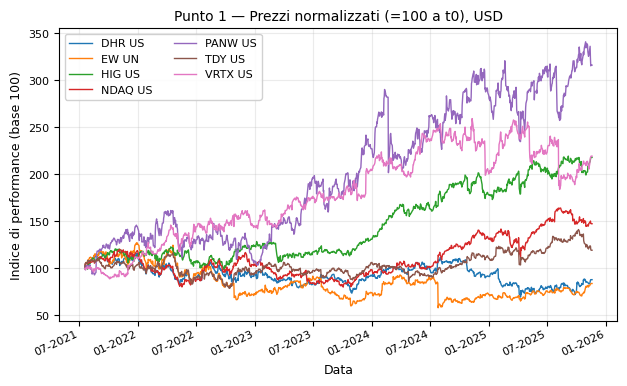

In [2]:
# =============================================================================
# PUNTO 1 — 7 equity da Excel: prezzi (USD), rendimenti, figure separate
# =============================================================================

EXCEL_CANDIDATE_NAMES = (
    "Business_Case_Valore_Rischio_2026_Light.xlsx",
    "Business_Case_Valore_Rischio_2026_Light (1).xlsx",
)


def _resolve_file_path() -> str:
    """Path Excel: env RM_FILE_PATH, poi ricerca in /content (Colab), cwd e Traccia Progetto/."""
    env = os.environ.get("RM_FILE_PATH")
    if env and os.path.isfile(env):
        return os.path.abspath(env)

    roots: list[str] = []
    if os.path.isdir("/content"):
        roots.append("/content")
    roots.append(os.getcwd())
    try:
        roots.append(os.path.dirname(os.path.abspath(__file__)))
    except NameError:
        pass
    roots = list(dict.fromkeys(os.path.abspath(r) for r in roots))

    subdirs = ("", "Traccia Progetto", "traccia progetto")
    candidates: list[str] = []
    for root in roots:
        for sub in subdirs:
            folder = os.path.join(root, sub) if sub else root
            for name in EXCEL_CANDIDATE_NAMES:
                candidates.append(os.path.join(folder, name))
            for pattern in ("Business_Case*.xlsx", "*Valore_Rischio*Light*.xlsx"):
                candidates.extend(sorted(glob.glob(os.path.join(folder, pattern))))

    seen: set[str] = set()
    for p in candidates:
        p = os.path.normpath(p)
        if p in seen:
            continue
        seen.add(p)
        if os.path.isfile(p):
            return p

    return os.path.join(roots[0] if roots else os.getcwd(), EXCEL_CANDIDATE_NAMES[0])


def _excel_not_found_message(path: str) -> str:
    roots = ["/content"] if os.path.isdir("/content") else []
    roots.append(os.getcwd())
    lines = [
        f"File Excel non trovato: {path}",
        "",
        "Su Google Colab (scegli una opzione):",
        "  A) Icona cartella a sinistra → carica il .xlsx in /content/",
        "  B) In questa cella, PRIMA di eseguire, decommenta il blocco COLAB_UPLOAD sotto",
        "  C) os.environ['RM_FILE_PATH'] = '/content/NOMEFILE.xlsx'",
        "",
        "In locale: copia il file in 'Traccia Progetto/' accanto al notebook.",
        "",
        "Nomi riconosciuti:",
        *[f"  - {n}" for n in EXCEL_CANDIDATE_NAMES],
        "",
        "Contenuto cartelle cercate:",
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        xlsx = sorted(glob.glob(os.path.join(root, "*.xlsx")))
        lines.append(f"  {root}: {xlsx if xlsx else '(nessun .xlsx)'}")
    return "\n".join(lines)


# Su Colab: decommenta le 3 righe sotto per caricare il file con dialog (una volta)
# from google.colab import files
# _up = files.upload()
# os.environ["RM_FILE_PATH"] = "/content/" + list(_up.keys())[0]

FILE_PATH = _resolve_file_path()
if not os.path.isfile(FILE_PATH):
    raise FileNotFoundError(_excel_not_found_message(FILE_PATH))

# 7 equity US (consegna); EW = Edwards Lifesciences (NYSE, prezzi USD nel dataset)
SELECTED_BB_TICKERS = [
    "DHR US Equity",
    "EW UN Equity",
    "HIG US EQUITY",
    "NDAQ US EQUITY",
    "PANW US EQUITY",
    "TDY US EQUITY",
    "VRTX US Equity",
]

# Pesi portafoglio (foglio Esercizio / report): mapping esplicito ticker -> peso
PORTFOLIO_WEIGHTS_BY_TICKER = {
    "DHR US Equity": 0.10,
    "EW UN Equity": 0.20,
    "HIG US EQUITY": 0.10,
    "NDAQ US EQUITY": 0.10,
    "PANW US EQUITY": 0.10,
    "TDY US EQUITY": 0.10,
    "VRTX US Equity": 0.20,
}
PORTFOLIO_WEIGHT_CASH = 0.10


def _match_ticker_key(ticker: str, pool: set[str]) -> str:
    if ticker in pool:
        return ticker
    up = {k.upper(): k for k in pool}
    return up[ticker.upper()]


def equity_weights_for_columns(cols) -> np.ndarray:
    w = []
    for c in cols:
        key = _match_ticker_key(c, set(PORTFOLIO_WEIGHTS_BY_TICKER))
        w.append(PORTFOLIO_WEIGHTS_BY_TICKER[key])
    return np.asarray(w, dtype=float)


def read_equity_prices_long(path: str, sheet: str = "Prezzi_Equity") -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    def row_equity_count(i: int) -> int:
        row = raw.iloc[i]
        return sum(
            1
            for j in range(1, raw.shape[1], 2)
            if isinstance(row.iloc[j], str) and "EQUITY" in row.iloc[j].upper()
        )

    header_row = max(range(min(10, len(raw))), key=row_equity_count)
    hdr = raw.iloc[header_row]

    parts = []
    for j in range(0, raw.shape[1] - 1, 2):
        ticker = hdr.iloc[j + 1]
        if not isinstance(ticker, str) or not str(ticker).strip():
            continue
        ticker = str(ticker).strip()

        dcol = raw.iloc[header_row + 1 :, j]
        pcol = raw.iloc[header_row + 1 :, j + 1]

        tmp = pd.DataFrame(
            {
                "date": pd.to_datetime(dcol, errors="coerce"),
                "ticker": ticker,
                "price_usd": pd.to_numeric(pcol, errors="coerce"),
            }
        )
        parts.append(tmp)

    out = pd.concat(parts, ignore_index=True)
    out = out.dropna(subset=["date", "price_usd"]).sort_values(["ticker", "date"])
    return out


prices_long = read_equity_prices_long(FILE_PATH)

# --- Check valuta: i ticker BBG con suffisso US/UN/UQ/UR/UW quotano in USD.
# Il foglio Excel contiene titoli di vari mercati (JPY/EUR/HKD/...): selezioniamo solo USD.
USD_BBG_SUFFIXES = {"US", "UN", "UQ", "UR", "UW"}


def _bbg_suffix(ticker: str) -> str:
    parts = ticker.strip().split()
    return parts[1].upper() if len(parts) >= 2 else ""


def assert_all_usd(tickers: list[str]) -> None:
    bad = [t for t in tickers if _bbg_suffix(t) not in USD_BBG_SUFFIXES]
    if bad:
        raise ValueError(
            f"I ticker selezionati devono essere quotati in USD "
            f"(suffisso BBG in {sorted(USD_BBG_SUFFIXES)}). Non-USD: {bad}"
        )


assert_all_usd(SELECTED_BB_TICKERS)
print(f"[VALUTA] I {len(SELECTED_BB_TICKERS)} ticker selezionati sono tutti in USD ✓")

_pool_tickers = set(prices_long["ticker"])
missing = [t for t in SELECTED_BB_TICKERS if _match_ticker_key(t, _pool_tickers) not in _pool_tickers]
if missing:
    raise ValueError(f"Ticker non trovati nel foglio: {missing}")

_pool = set(prices_long["ticker"])
selected_resolved = [_match_ticker_key(t, _pool) for t in SELECTED_BB_TICKERS]
prices = (
    prices_long[prices_long["ticker"].isin(selected_resolved)]
    .pivot(index="date", columns="ticker", values="price_usd")
    .sort_index()
)
prices = prices[~prices.index.duplicated(keep="last")]
prices = prices[selected_resolved]  # ordine fisso coerente con pesi/report
PORTFOLIO_WEIGHTS_EQUITY = equity_weights_for_columns(prices.columns)
assert np.isclose(float(PORTFOLIO_WEIGHTS_EQUITY.sum() + PORTFOLIO_WEIGHT_CASH), 1.0)

print("Periodo campione (date osservazioni):")
print(" da", prices.index.min(), " a ", prices.index.max())
print("Shape prezzi:", prices.shape)
display(prices.tail())

returns_log = np.log(prices / prices.shift(1)).dropna(how="all")

print("\nAnteprima rendimenti LOG:")
display(returns_log.head())

# Figura report Punto 1: confronto prezzi normalizzati (compatta, 1 pagina PDF)
px = prices.dropna(how="all").ffill()
norm100 = (px / px.iloc[0]) * 100.0

fig_p1, ax = plt.subplots(figsize=(7.2, 3.8))
for col in norm100.columns:
    ax.plot(norm100.index, norm100[col], linewidth=1.0, label=short_ticker(col))
ax.set_title("Punto 1 — Prezzi normalizzati (=100 a t0), USD")
ax.set_ylabel("Indice di performance (base 100)")
ax.set_xlabel("Data")
ax.grid(True, alpha=0.25)
ax.legend(ncol=2, loc="upper left", framealpha=0.9)
style_time_axis(ax)
apply_report_style(fig_p1)


In [3]:
maybe_save(fig_p1, "p1_prices_normalized_report")
plt.show()
plt.close(fig_p1)


[SAVE] /content/figures/p1_prices_normalized_report.pdf
[SAVE] /content/figures/p1_prices_normalized_report.png


In [4]:
# =============================================================================
# PUNTO 2 — DATI + FIGURE (una figura per blocco, salva file separati)
# =============================================================================

TRADING_DAYS = 252

# Consegna: vol su finestre 1D (freq.), 1M, 1Y. Il 3M e' un'estensione diagnostica.
ROLL_WINDOWS_D = {
    "1M (≈21g)": 21,
    "3M (≈63g)": 63,  # opzionale (non richiesto esplicitamente dalla traccia)
    "1Y (≈252g)": 252,
}

EWMA_LAMBDA = 0.94
EWMA_WARMUP = 30  # giorni per varianza iniziale (poi ricorsione EWMA su tutta la serie)


def ewma_lambda_from_span(span: int) -> float:
    """Lambda equivalente RiskMetrics per pandas ewm(span, adjust=False): lam = 1 - 2/(span+1)."""
    return float(1.0 - 2.0 / (span + 1))


def label_ewma_riskmetrics(lam: float = EWMA_LAMBDA, warmup_days: int = EWMA_WARMUP) -> str:
    """EWMA long-memory (RiskMetrics): inizializzazione su warmup_days, poi decay lam."""
    return f"EWMA ann. (iniz. {warmup_days} gg, $\\lambda$={lam:.2f})"


def label_ewma_window(days: int, lam: float | None = None, *, prefix: str = "EWMA") -> str:
    """EWMA su finestra equivalente a `days` giorni (pandas span=days)."""
    lam_v = ewma_lambda_from_span(days) if lam is None else float(lam)
    return f"{prefix} ({days} gg, $\\lambda$={lam_v:.3f})"

GARCH_P = 1
GARCH_Q = 1

if "prices" not in globals() or "returns_log" not in globals():
    raise NameError("Esegui prima la cella del Punto 1 per popolare `prices` e `returns_log`.")

returns_lw = returns_log.dropna(how="any").copy()
n_obs_lw = len(returns_lw)

# Test di significativita' sulle correlazioni pairwise (indicazioni docente):
# H0: rho_ij = 0; statistica t = rho * sqrt((n-2)/(1-rho^2)) ~ t_{n-2} (due code).
# n = osservazioni della serie temporale usata per stimare rho (Pearson, listwise).
# Livello alpha: parametro utente (motivazione standard risk management / reporting).
CORR_SIGNIFICANCE_ALPHA = 0.05
# Motivazione (nota prof.): alpha scelto come standard risk reporting; modificabile (es. 10%).
CORR_SIGNIFICANCE_RATIONALE = (
    "Soglia alpha=5% (due code) per il test sulle correlazioni: convenzione standard "
    "nel risk management e nei report direzionali; equivalente a confidenza 95% "
    "nel rifiuto di H0: rho_ij=0."
)

# ---------------------------------------------------------------------------
# Testo da copiare nel report (LaTeX): cosa significa "1D" per vol e rendimenti
# ---------------------------------------------------------------------------
REPORT_PUNTO2_VOCE_1D_IT = """
Notazione ``1D'' (Punto 2 — volatilità).

In tutta l'analisi del Punto 2 si utilizzano rendimenti LOGARITMICI GIORNALIERI
    g_t = ln(P_t / P_{t-1})
dove P_t è il prezzo (USD) alla data t e il passo temporale tra due osservazioni
consecutive è un GIORNO di mercato.

Con ``1D'' non si intende una finestra mobile di lunghezza un giorno (che non
avrebbe senso per stimare la volatilità), bensì il fatto che la FREQUENZA di
campionamento dei rendimenti è giornaliera: la volatilità ``alla giornata''
è la deviazione standard dei rendimenti giornalieri,

    sigma_giorno = std(g_t)   (stima campionaria sui g_t, tipicamente ddof=1).

Per esprimere la volatilità su orizzonte annuale si applica la usualizzazione
in radice del tempo (scaling sqrt-rule) con H=252 giorni di negoziazione:

    sigma_ann = sigma_giorno * sqrt(252).

Le volatilità ``a finestre'' più lunghe (es. 1M, 1Y) si ottengono invece da
finestre ROLLING di g_t (sempre rendimenti giornalieri dentro la finestra),
poi annualizzate con lo stesso fattore sqrt(252) applicato alla deviazione
standard giornaliera stimata su quella finestra.
""".strip()

REPORT_PUNTO2_VOCE_1D_LATEX = r"""
\subsection*{Notazione $1$D (frequenza giornaliera, non finestra $1$ giorno)}
Nel Punto~2 i rendimenti sono \emph{log-rendimenti giornalieri}
\[
  g_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right),
\]
con $P_t$ prezzo in USD e passo temporale tra osservazioni consecutive pari a un giorno di mercato.

Con ``$1$D'' si intende la \emph{frequenza} di campionamento (giornaliera), \emph{non} una finestra mobile di ampiezza un giorno (insufficiente per una volatilità significativa). La volatilità alla giornata è la deviazione standard dei $g_t$,
\[
  \sigma_{\mathrm{giorno}} = \widehat{\mathrm{st.dev.}}(g_t).
\]
L'annualizzazione (convenzione $H=252$ giorni di negoziazione) è
\[
  \sigma_{\mathrm{ann}} = \sigma_{\mathrm{giorno}}\,\sqrt{252}.
\]
Le volatilità su orizzonti tipo $1$M o $1$Y si ottengono invece applicando la stessa annualizzazione a deviazioni standard di $g_t$ stimate su \emph{finestre mobili} di lunghezza in giorni (es.\ $21$, $252$).
""".strip()

print("\n" + "=" * 72)
print("REPORT — Punto 2: testo sulla notazione 1D / vol (copia nel PDF)")
print("=" * 72)
print(REPORT_PUNTO2_VOCE_1D_IT)
print("\n--- Blocco LaTeX (copia nel .tex) ---\n")
print(REPORT_PUNTO2_VOCE_1D_LATEX)
print("=" * 72 + "\n")

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        out_tex = os.path.join(FIG_DIR, "p2_report_snippet_vol_1d.tex")
        with open(out_tex, "w", encoding="utf-8") as f:
            f.write("% --- Generato da untitled16.py (Punto 2, notazione 1D) ---\n\n")
            f.write(REPORT_PUNTO2_VOCE_1D_LATEX)
            f.write("\n")
        print(f"[SAVE] Snippet LaTeX (1D) -> {os.path.abspath(out_tex)}")
    except OSError as e:
        print(f"[SAVE] Snippet LaTeX non salvato: {e}")



REPORT — Punto 2: testo sulla notazione 1D / vol (copia nel PDF)
Notazione ``1D'' (Punto 2 — volatilità).

In tutta l'analisi del Punto 2 si utilizzano rendimenti LOGARITMICI GIORNALIERI
    g_t = ln(P_t / P_{t-1})
dove P_t è il prezzo (USD) alla data t e il passo temporale tra due osservazioni
consecutive è un GIORNO di mercato.

Con ``1D'' non si intende una finestra mobile di lunghezza un giorno (che non
avrebbe senso per stimare la volatilità), bensì il fatto che la FREQUENZA di
campionamento dei rendimenti è giornaliera: la volatilità ``alla giornata''
è la deviazione standard dei rendimenti giornalieri,

    sigma_giorno = std(g_t)   (stima campionaria sui g_t, tipicamente ddof=1).

Per esprimere la volatilità su orizzonte annuale si applica la usualizzazione
in radice del tempo (scaling sqrt-rule) con H=252 giorni di negoziazione:

    sigma_ann = sigma_giorno * sqrt(252).

Le volatilità ``a finestre'' più lunghe (es. 1M, 1Y) si ottengono invece da
finestre ROLLING di g_t (semp

In [5]:
def years_between(idx: pd.DatetimeIndex) -> float:
    return (idx[-1] - idx[0]) / np.timedelta64(1, "D") / 365.25


def build_summary_tables(prices_df: pd.DataFrame, returns_df: pd.DataFrame):
    rows = []
    for col in prices_df.columns:
        p = prices_df[col].dropna()
        r = returns_df[col].reindex(p.index).dropna()

        p0, pT = p.iloc[0], p.iloc[-1]
        total_simple = pT / p0 - 1.0
        total_log = float(np.log(pT / p0))

        yy = years_between(p.index)
        cagr = (pT / p0) ** (1.0 / yy) - 1.0 if yy > 0 else np.nan

        sig_d = r.std(ddof=1)

        rows.append(
            {
                "ticker": col,
                "n_prices": int(p.shape[0]),
                "n_returns": int(r.shape[0]),
                "start": p.index.min(),
                "end": p.index.max(),
                "years": yy,
                "total_return_simple": total_simple,
                "total_return_log": total_log,
                "CAGR": cagr,
                "mean_logret_daily": r.mean(),
                "vol_logret_daily": sig_d,
                "vol_logret_ann_static": sig_d * np.sqrt(TRADING_DAYS),
                "skew_logret": r.skew(),
                "excess_kurt_logret": r.kurt(),
                "JB_stat": float(stats.jarque_bera(r.dropna())[0]),
                "JB_pvalue": float(stats.jarque_bera(r.dropna())[1]),
            }
        )

    summary_assets = pd.DataFrame(rows).set_index("ticker")

    roll_last = {}
    for name, w in ROLL_WINDOWS_D.items():
        roll_last[name] = (
            returns_df.rolling(window=w, min_periods=w).std(ddof=1) * np.sqrt(TRADING_DAYS)
        ).iloc[-1]

    roll_vol_last = pd.DataFrame(roll_last).T.rename_axis("window")
    return summary_assets, roll_vol_last


summary_assets, roll_vol_last = build_summary_tables(prices, returns_log)

if SAVE_SUMMARY_CSV and SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        summary_assets.to_csv(os.path.join(FIG_DIR, "p2_summary_assets.csv"))
        roll_vol_last.to_csv(os.path.join(FIG_DIR, "p2_rolling_vol_last.csv"))
    except OSError as e:
        print(f"[SAVE] CSV summary P2: {e}")

print("=== Summary per titolo ===")
display(summary_assets)

print("\n=== Vol rolling (ultima osservazione) ===")
display(roll_vol_last)

# --- Outlier check: log-rendimenti |g_t| > 20% (di solito earnings shock o eventi)
OUTLIER_THRESHOLD = 0.20
print(f"\n=== Outlier check (|g_t| > {OUTLIER_THRESHOLD:.0%}) ===")
outlier_rows = []
for col in returns_log.columns:
    s = returns_log[col].dropna()
    big = s[s.abs() > OUTLIER_THRESHOLD]
    for d, v in big.items():
        outlier_rows.append({"ticker": col, "date": d.date(), "log_ret": float(v)})
if outlier_rows:
    out_df = pd.DataFrame(outlier_rows).sort_values("log_ret", key=abs, ascending=False)
    display(out_df)
    print("Nota: gli outlier sono mantenuti nel campione (eventi di mercato reali, es. earnings).")
else:
    print("Nessun outlier > soglia.")


def ewma_vol_ann(r: pd.Series, lam: float = EWMA_LAMBDA, warmup: int = EWMA_WARMUP) -> pd.Series:
    r = r.dropna().astype(float)
    var = np.full(shape=len(r), dtype=float, fill_value=np.nan)
    if len(r) <= warmup + 1:
        return pd.Series(var, index=r.index)

    w = r.iloc[:warmup].to_numpy(float)
    var[warmup] = float(np.var(w, ddof=1))
    rv = r.to_numpy(float)
    for t in range(warmup + 1, len(r)):
        var[t] = lam * var[t - 1] + (1.0 - lam) * (rv[t - 1] ** 2)

    vol_d = np.sqrt(var)
    return pd.Series(vol_d * np.sqrt(TRADING_DAYS), index=r.index)


ewma_vol_ann_df = pd.DataFrame({c: ewma_vol_ann(returns_log[c]) for c in returns_log.columns})

# Vol annualizzata su orizzonte ~1 mese (21 giornari): SMA su r^2 e EWMA (span=21 gg)
VOL_1M_DAYS = ROLL_WINDOWS_D["1M (≈21g)"]
EWMA_1M_LAMBDA = ewma_lambda_from_span(VOL_1M_DAYS)


def sma_vol_ann_1m(r: pd.Series, window: int = VOL_1M_DAYS) -> pd.Series:
    """Vol 'SMA': sqrt(media mobile dei quadrati dei log-rendimenti) * sqrt(252)."""
    r = r.astype(float)
    m2 = (r**2).rolling(window=window, min_periods=window).mean()
    return np.sqrt(m2 * TRADING_DAYS)


def ewma_vol_ann_1m(r: pd.Series, span: int = VOL_1M_DAYS) -> pd.Series:
    """EWMA (pandas) su span=giorni (~1M); vol annualizzata; lambda equiv. = 1-2/(span+1)."""
    r = r.astype(float)
    v = r.ewm(span=span, adjust=False).var(bias=True)
    return np.sqrt(np.maximum(v, 0.0) * TRADING_DAYS)


sma_vol_1m_ann = pd.DataFrame({c: sma_vol_ann_1m(returns_log[c]) for c in returns_log.columns})
ewma_vol_1m_ann = pd.DataFrame({c: ewma_vol_ann_1m(returns_log[c]) for c in returns_log.columns})


def _params_summary(res, model_label: str, asset_name: str) -> pd.DataFrame:
    pdict = res.params.to_dict()
    row: dict = {
        "model": model_label,
        "AIC": res.aic,
        "BIC": res.bic,
        "nu": pdict.get("nu", np.nan),
    }
    for k in ["omega", "alpha[1]", "beta[1]", "gamma[1]"]:
        if k in pdict:
            row[k] = pdict[k]
    a = row.get("alpha[1]", np.nan)
    b = row.get("beta[1]", np.nan)
    if np.isfinite(a) and np.isfinite(b):
        row["persistence_alpha_plus_beta"] = float(a) + float(b)
    else:
        row["persistence_alpha_plus_beta"] = np.nan
    return pd.DataFrame([row], index=[asset_name])


def fit_vol_model_ann(r: pd.Series, scale: float = 100.0) -> tuple[pd.Series, pd.DataFrame]:
    """
    Stima vol condizionata annualizzata con strategia robusta:
    1) GARCH(1,1) con innovazioni Student-t (più sensate su equity daily)
    2) se beta GARCH ~ 0 (soluzione di confine / vol quasi costante): EGARCH(1,1,1) Student-t
    3) fallback: GARCH(1,1) normale
    4) ultimo fallback: EGARCH(1,1,1) normale
    """
    asset_name = r.name if r.name is not None else "asset"
    y_raw = r.dropna().astype(float)
    idx = y_raw.index
    y_scaled = (y_raw * scale).rename("y")

    def to_vol_ann(res) -> pd.Series:
        sigma_scaled = pd.Series(res.conditional_volatility, index=idx)
        sigma = sigma_scaled / scale
        return sigma * np.sqrt(TRADING_DAYS)

    def fit_or_none(build):
        try:
            m = build()
            return m.fit(update_freq=0, disp="off", options={"maxiter": 10000})
        except Exception:
            return None

    # --- 1) GARCH-t
    res_gt = fit_or_none(
        lambda: arch_model(
            y_scaled,
            mean="Constant",
            vol="GARCH",
            p=GARCH_P,
            q=GARCH_Q,
            dist="studentst",
        )
    )
    if res_gt is not None:
        beta = float(res_gt.params.get("beta[1]", np.nan))
        if np.isfinite(beta) and beta > 1e-4:
            return to_vol_ann(res_gt), _params_summary(res_gt, "GARCH(1,1)-StudentT", asset_name)

    # --- 2) EGARCH-t (evita GARCH quasi degeneri con beta≈0)
    res_et = fit_or_none(
        lambda: arch_model(
            y_scaled,
            mean="Constant",
            vol="EGARCH",
            p=1,
            o=1,
            q=1,
            dist="studentst",
        )
    )
    if res_et is not None:
        return to_vol_ann(res_et), _params_summary(res_et, "EGARCH(1,1,1)-StudentT", asset_name)

    # --- 3) GARCH-normal
    res_gn = fit_or_none(
        lambda: arch_model(
            y_scaled,
            mean="Constant",
            vol="GARCH",
            p=GARCH_P,
            q=GARCH_Q,
            dist="normal",
        )
    )
    if res_gn is not None:
        beta = float(res_gn.params.get("beta[1]", np.nan))
        if np.isfinite(beta) and beta > 1e-4:
            return to_vol_ann(res_gn), _params_summary(res_gn, "GARCH(1,1)-Normal", asset_name)

    # --- 4) EGARCH-normal
    res_en = fit_or_none(
        lambda: arch_model(
            y_scaled,
            mean="Constant",
            vol="EGARCH",
            p=1,
            o=1,
            q=1,
            dist="normal",
        )
    )
    if res_en is not None:
        return to_vol_ann(res_en), _params_summary(res_en, "EGARCH(1,1,1)-Normal", asset_name)

    raise RuntimeError(f"Impossibile stimare un modello ARCH per {asset_name}")


garch_vol_ann: dict[str, pd.Series] = {}
garch_params: list[pd.DataFrame] = []
for c in returns_log.columns:
    v, par = fit_vol_model_ann(returns_log[c].rename(c))
    garch_vol_ann[c] = v
    garch_params.append(par)

garch_vol_ann = pd.concat(garch_vol_ann, axis=1)
garch_params_df = pd.concat(garch_params, axis=0)

print("\n=== Modelli vol condizionata (parametri stimati MLE, non fissati a mano) ===")
print(
    "Specifiche: (1) GARCH(1,1) + Student-t; se beta_hat<=1e-4 (confine) -> "
    "(2) EGARCH(1,1,1) + Student-t; se fallisce -> (3) GARCH Normal; -> (4) EGARCH Normal.\n"
    "Rendimenti in stima: log-rendimenti * 100 (scala numerica arch); vol ann. = sigma_daily * sqrt(252).\n"
    "Colonne: omega, alpha[1], beta[1] (GARCH) o +gamma[1] (EGARCH), nu (gradi liberta t, se presente), AIC/BIC."
)
display(garch_params_df)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        csv_path = os.path.join(FIG_DIR, "p2_vol_model_params.csv")
        garch_params_df.to_csv(csv_path)
        print(f"[SAVE] Tabella parametri -> {os.path.abspath(csv_path)}")
    except OSError as e:
        print(f"[SAVE] CSV parametri non salvato: {e}")


=== Summary per titolo ===


,n_prices,n_returns,start,end,years,total_return_simple,total_return_log,CAGR,mean_logret_daily,vol_logret_daily,vol_logret_ann_static,skew_logret,excess_kurt_logret,JB_stat,JB_pvalue
ticker,,,,,,,,,,,,,,,
DHR US Equity,1131,1130,2021-07-19,2025-11-17,4.33128,-0.120484,-0.128383,-0.029206,-0.000114,0.017469,0.277308,0.016550,4.452154,922.878603,3.976103e-201
EW UN Equity,1131,1130,2021-07-19,2025-11-17,4.33128,-0.161403,-0.176025,-0.039826,-0.000156,0.021815,0.346304,-5.211452,84.057811,334803.143578,0.000000e+00
HIG US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,1.180678,0.779636,0.197219,0.000690,0.013772,0.218630,-0.390157,3.309996,538.246833,1.321859e-117
NDAQ US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,0.474682,0.388443,0.093828,0.000344,0.014638,0.232365,-0.751183,7.649559,2833.005688,0.000000e+00
PANW US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,2.162217,1.151273,0.304480,0.001019,0.026072,0.413877,-1.400988,27.745649,36280.962104,0.000000e+00
TDY US EQUITY,1131,1130,2021-07-19,2025-11-17,4.33128,0.192666,0.176192,0.041518,0.000156,0.014798,0.234904,-0.620512,6.211503,1869.818995,0.000000e+00
VRTX US Equity,1131,1130,2021-07-19,2025-11-17,4.33128,1.194088,0.785766,0.198915,0.000695,0.017877,0.283794,-2.071557,30.676168,44706.760480,0.000000e+00



=== Vol rolling (ultima osservazione) ===


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
window,,,,,,,
1M (≈21g),0.261458,0.236394,0.144369,0.205238,0.244363,0.263851,0.178699
3M (≈63g),0.315409,0.196487,0.165861,0.200867,0.226642,0.216676,0.197059
1Y (≈252g),0.325086,0.237917,0.212152,0.235353,0.344975,0.226665,0.363548



=== Outlier check (|g_t| > 20%) ===


,ticker,date,log_ret
0,EW UN Equity,2024-07-25,-0.376001
1,PANW US EQUITY,2024-02-21,-0.334649
2,VRTX US Equity,2025-08-05,-0.230678


Nota: gli outlier sono mantenuti nel campione (eventi di mercato reali, es. earnings).

=== Modelli vol condizionata (parametri stimati MLE, non fissati a mano) ===
Specifiche: (1) GARCH(1,1) + Student-t; se beta_hat<=1e-4 (confine) -> (2) EGARCH(1,1,1) + Student-t; se fallisce -> (3) GARCH Normal; -> (4) EGARCH Normal.
Rendimenti in stima: log-rendimenti * 100 (scala numerica arch); vol ann. = sigma_daily * sqrt(252).
Colonne: omega, alpha[1], beta[1] (GARCH) o +gamma[1] (EGARCH), nu (gradi liberta t, se presente), AIC/BIC.


,model,AIC,BIC,nu,omega,alpha[1],beta[1],persistence_alpha_plus_beta
DHR US Equity,"GARCH(1,1)-StudentT",4276.951185,4302.101050,3.976423,0.699478,0.137436,0.654523,0.791959
EW UN Equity,"GARCH(1,1)-StudentT",4413.920446,4439.070311,3.358425,0.564753,0.076703,0.783449,0.860153
HIG US EQUITY,"GARCH(1,1)-StudentT",3764.313193,3789.463058,4.780803,0.273918,0.126244,0.736524,0.862767
NDAQ US EQUITY,"GARCH(1,1)-StudentT",3853.206323,3878.356187,3.995761,0.278867,0.118937,0.763902,0.882838
PANW US EQUITY,"GARCH(1,1)-StudentT",5005.670662,5030.820527,3.346867,2.989880,0.140469,0.424253,0.564721
TDY US EQUITY,"GARCH(1,1)-StudentT",3876.836320,3901.986185,3.828702,0.162836,0.073277,0.859904,0.933181
VRTX US Equity,"GARCH(1,1)-StudentT",4102.525513,4127.675377,3.814772,0.944266,0.173876,0.501410,0.675286


[SAVE] Tabella parametri -> /content/figures/p2_vol_model_params.csv


In [6]:
def corr_and_pvalues(
    df: pd.DataFrame,
    *,
    alpha: float = CORR_SIGNIFICANCE_ALPHA,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Matrice di correlazione di Pearson e test H0: rho_ij = 0 (due code).

    Per ogni coppia (i,j), i=j+1:
        t_ij = rho_ij * sqrt((n-2) / (1 - rho_ij^2)),   gradi di liberta' = n-2
        p_ij = 2 * P(T_{n-2} >= |t_ij|)
    con n = numero di osservazioni listwise sul campione comune.
    """
    x = df.dropna(how="any")
    n = int(x.shape[0])
    if n < 3:
        raise ValueError("Servono almeno 3 osservazioni per il test sulle correlazioni.")

    R = x.corr(method="pearson")
    P = pd.DataFrame(np.nan, index=R.index, columns=R.columns, dtype=float)
    T = pd.DataFrame(np.nan, index=R.index, columns=R.columns, dtype=float)
    cols = list(R.columns)
    df_t = n - 2
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            rij = float(R.iloc[i, j])
            denom = max(1e-12, 1.0 - rij**2)
            t_stat = rij * np.sqrt(df_t / denom)
            p_val = float(2.0 * (1.0 - stats.t.cdf(abs(t_stat), df=df_t)))
            for r, c, v_t, v_p in (
                (i, j, t_stat, p_val),
                (j, i, t_stat, p_val),
            ):
                T.iloc[r, c] = v_t
                P.iloc[r, c] = v_p

    sig_mask = (P < alpha) & (~np.eye(len(cols), dtype=bool))
    return R, P, T, sig_mask.astype(bool)


def corr_significant_pairs_table(
    R: pd.DataFrame,
    P: pd.DataFrame,
    T: pd.DataFrame,
    *,
    alpha: float = CORR_SIGNIFICANCE_ALPHA,
) -> pd.DataFrame:
    """Tabella coppie (i<j) con rho, t, p e flag significativita' al livello alpha."""
    cols = list(R.columns)
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            p_ij = float(P.iloc[i, j])
            rows.append(
                {
                    "asset_i": cols[i],
                    "asset_j": cols[j],
                    "rho": float(R.iloc[i, j]),
                    "t_stat": float(T.iloc[i, j]),
                    "p_value": p_ij,
                    "significant_at_alpha": bool(p_ij < alpha),
                }
            )
    return pd.DataFrame(rows)


R, P, T_corr, corr_sig_mask = corr_and_pvalues(returns_lw, alpha=CORR_SIGNIFICANCE_ALPHA)
corr_pairs_table = corr_significant_pairs_table(
    R, P, T_corr, alpha=CORR_SIGNIFICANCE_ALPHA
)
n_sig_pairs = int(corr_pairs_table["significant_at_alpha"].sum())
n_pairs = len(corr_pairs_table)

print(f"\nListwise n (Pearson + test t su H0: rho=0): {n_obs_lw}")
print(f"Livello di significativita' alpha={CORR_SIGNIFICANCE_ALPHA:.0%} (due code).")
print(CORR_SIGNIFICANCE_RATIONALE)
print(f"Coppie significative: {n_sig_pairs} / {n_pairs}")
display(R.round(3))
display(T_corr.round(3))
display(P.round(4))
display(corr_pairs_table.round(4))

REPORT_PUNTO2_CORR_TEST_LATEX = rf"""
\subsection*{{Test di significativita' sulle correlazioni (Punto 2)}}
Sulla matrice di correlazione di Pearson tra log-rendimenti giornalieri (campione listwise,
$n={n_obs_lw}$) si testa, per ogni coppia $(i,j)$, $H_0:\rho_{{ij}}=0$ contro l'alternativa
bilaterale $\rho_{{ij}}\neq 0$, con
\[
  t_{{ij}}=\hat\rho_{{ij}}\sqrt{{\frac{{n-2}}{{1-\hat\rho_{{ij}}^2}}}}
  \;\sim\; t_{{n-2}}.
\]
Si rifiuta $H_0$ se $p_{{ij}}<\alpha$, con $\alpha={CORR_SIGNIFICANCE_ALPHA}$ scelto come
soglia convenzionale nel risk reporting (equivalente a confidenza $1-\alpha$).
Risultato: {n_sig_pairs} coppie significative su {n_pairs} al livello $\alpha={CORR_SIGNIFICANCE_ALPHA}$.
""".strip()

print("\n--- Snippet LaTeX (test correlazioni) ---\n")
print(REPORT_PUNTO2_CORR_TEST_LATEX)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        corr_pairs_table.to_csv(os.path.join(FIG_DIR, "p2_correlation_significance_pairs.csv"), index=False)
        with open(os.path.join(FIG_DIR, "p2_report_snippet_corr_test.tex"), "w", encoding="utf-8") as f:
            f.write("% --- Generato: test significativita correlazioni (Punto 2) ---\n\n")
            f.write(REPORT_PUNTO2_CORR_TEST_LATEX + "\n")
        print(f"[SAVE] Tabella/snippet test correlazioni in {os.path.abspath(FIG_DIR)}")
    except OSError as e:
        print(f"[SAVE] Export test correlazioni non salvato: {e}")

win_1y_name = "1Y (≈252g)"
win_1y = ROLL_WINDOWS_D[win_1y_name]
roll_ann_1y = returns_log.rolling(window=win_1y, min_periods=win_1y).std(ddof=1) * np.sqrt(TRADING_DAYS)


# style_time_axis / maybe_save: vedi cella setup iniziale



Listwise n (Pearson + test t su H0: rho=0): 1130
Livello di significativita' alpha=5% (due code).
Soglia alpha=5% (due code) per il test sulle correlazioni: convenzione standard nel risk management e nei report direzionali; equivalente a confidenza 90% nel rifiuto di H0: rho_ij=0.
Coppie significative: 21 / 21


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
ticker,,,,,,,
DHR US Equity,1.000,0.318,0.301,0.445,0.295,0.419,0.276
EW UN Equity,0.318,1.000,0.204,0.251,0.252,0.298,0.142
HIG US EQUITY,0.301,0.204,1.000,0.393,0.168,0.448,0.195
NDAQ US EQUITY,0.445,0.251,0.393,1.000,0.320,0.460,0.228
PANW US EQUITY,0.295,0.252,0.168,0.320,1.000,0.317,0.192
TDY US EQUITY,0.419,0.298,0.448,0.460,0.317,1.000,0.231
VRTX US Equity,0.276,0.142,0.195,0.228,0.192,0.231,1.000


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
ticker,,,,,,,
DHR US Equity,NaN,11.268,10.618,16.667,10.352,15.495,9.630
EW UN Equity,11.268,NaN,7.003,8.705,8.745,10.487,4.812
HIG US EQUITY,10.618,7.003,NaN,14.362,5.710,16.840,6.683
NDAQ US EQUITY,16.667,8.705,14.362,NaN,11.348,17.422,7.868
PANW US EQUITY,10.352,8.745,5.710,11.348,NaN,11.215,6.571
TDY US EQUITY,15.495,10.487,16.840,17.422,11.215,NaN,7.975
VRTX US Equity,9.630,4.812,6.683,7.868,6.571,7.975,NaN


ticker,DHR US Equity,EW UN Equity,HIG US EQUITY,NDAQ US EQUITY,PANW US EQUITY,TDY US EQUITY,VRTX US Equity
ticker,,,,,,,
DHR US Equity,NaN,0.0,0.0,0.0,0.0,0.0,0.0
EW UN Equity,0.0,NaN,0.0,0.0,0.0,0.0,0.0
HIG US EQUITY,0.0,0.0,NaN,0.0,0.0,0.0,0.0
NDAQ US EQUITY,0.0,0.0,0.0,NaN,0.0,0.0,0.0
PANW US EQUITY,0.0,0.0,0.0,0.0,NaN,0.0,0.0
TDY US EQUITY,0.0,0.0,0.0,0.0,0.0,NaN,0.0
VRTX US Equity,0.0,0.0,0.0,0.0,0.0,0.0,NaN


,asset_i,asset_j,rho,t_stat,p_value,significant_at_alpha
0,DHR US Equity,EW UN Equity,0.3181,11.2679,0.0,True
1,DHR US Equity,HIG US EQUITY,0.3014,10.6178,0.0,True
2,DHR US Equity,NDAQ US EQUITY,0.4445,16.6670,0.0,True
3,DHR US Equity,PANW US EQUITY,0.2945,10.3518,0.0,True
4,DHR US Equity,TDY US EQUITY,0.4189,15.4947,0.0,True
5,DHR US Equity,VRTX US Equity,0.2756,9.6295,0.0,True
6,EW UN Equity,HIG US EQUITY,0.2041,7.0033,0.0,True
7,EW UN Equity,NDAQ US EQUITY,0.2509,8.7050,0.0,True
8,EW UN Equity,PANW US EQUITY,0.2520,8.7446,0.0,True
9,EW UN Equity,TDY US EQUITY,0.2980,10.4867,0.0,True



--- Snippet LaTeX (test correlazioni) ---

\subsection*{Test di significativita' sulle correlazioni (Punto 2)}
Sulla matrice di correlazione di Pearson tra log-rendimenti giornalieri (campione listwise,
$n=1130$) si testa, per ogni coppia $(i,j)$, $H_0:\rho_{ij}=0$ contro l'alternativa
bilaterale $\rho_{ij}\neq 0$, con
\[
  t_{ij}=\hat\rho_{ij}\sqrt{\frac{n-2}{1-\hat\rho_{ij}^2}}
  \;\sim\; t_{n-2}.
\]
Si rifiuta $H_0$ se $p_{ij}<\alpha$, con $\alpha=0.05$ scelto come
soglia convenzionale nel risk reporting (equivalente a confidenza $1-\alpha$).
Risultato: 21 coppie significative su 21 al livello $\alpha=0.05$.
[SAVE] Tabella/snippet test correlazioni in /content/figures


[SAVE] /content/figures/p2_returns_summary.pdf
[SAVE] /content/figures/p2_returns_summary.png


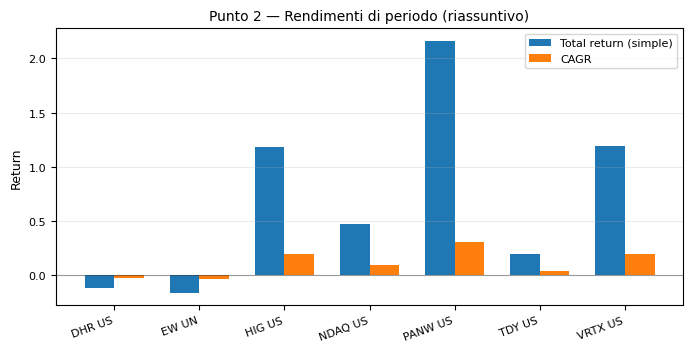

[SAVE] /content/figures/p2_vol_summary_static_vs_roll1y.pdf
[SAVE] /content/figures/p2_vol_summary_static_vs_roll1y.png


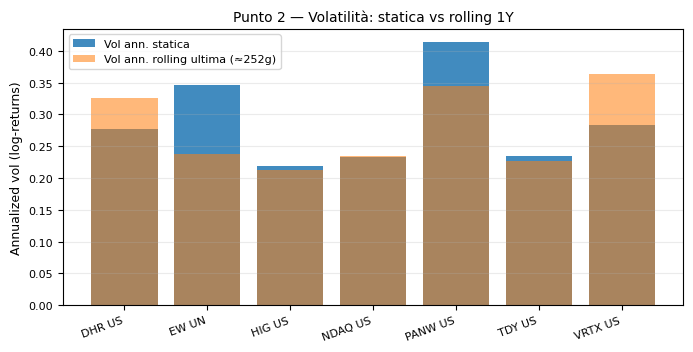

In [7]:
# --- Figure Punto 2 (una per blocco) -----------------------------------------

fig, ax = plt.subplots(figsize=(7.0, 3.6))
x = np.arange(len(summary_assets))
w = 0.35
ax.bar(x - w / 2, summary_assets["total_return_simple"].values, width=w, label="Total return (simple)")
ax.bar(x + w / 2, summary_assets["CAGR"].values, width=w, label="CAGR")
ax.set_xticks(x)
ax.set_xticklabels([short_ticker(t) for t in summary_assets.index], rotation=20, ha="right")
ax.axhline(0, color="black", linewidth=0.8, alpha=0.35)
ax.set_title("Punto 2 — Rendimenti di periodo (riassuntivo)")
ax.set_ylabel("Return")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
maybe_save(fig, "p2_returns_summary")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7.0, 3.6))

roll_1y_last = roll_vol_last.loc[win_1y_name].reindex(summary_assets.index)

lbls = [short_ticker(t) for t in summary_assets.index]
ax.bar(lbls, summary_assets["vol_logret_ann_static"].values, alpha=0.85, label="Vol ann. statica")
ax.bar(lbls, roll_1y_last.values, alpha=0.55, label="Vol ann. rolling ultima (≈252g)")
ax.set_title("Punto 2 — Volatilità: statica vs rolling 1Y")
ax.set_ylabel("Annualized vol (log-returns)")
plt.xticks(rotation=20, ha="right")
ax.grid(True, axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
maybe_save(fig, "p2_vol_summary_static_vs_roll1y")
plt.show()
plt.close(fig)

if SAVE_P2_BOXPLOT:
    fig, ax = plt.subplots(figsize=(7.0, 3.4))
    data = [returns_log[c].dropna().values for c in returns_log.columns]
    ax.boxplot(
        data,
        tick_labels=[short_ticker(c) for c in returns_log.columns],
        showfliers=False,
    )
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.35)
    ax.set_title("Punto 2 — Boxplot log-rendimenti")
    ax.set_ylabel("g_t")
    plt.xticks(rotation=25, ha="right")
    ax.grid(True, axis="y", alpha=0.25)
    apply_report_style(fig)
    maybe_save(fig, "p2_boxplot_logreturns")
    plt.show()
    plt.close(fig)


[SAVE] /content/figures/p2_corr_heatmap.pdf
[SAVE] /content/figures/p2_corr_heatmap.png


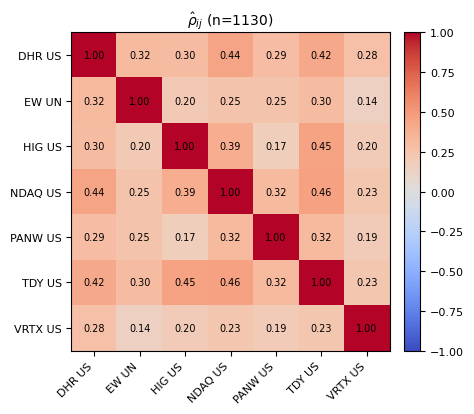

[SAVE] /content/figures/p2_corr_pvalues_heatmap.pdf
[SAVE] /content/figures/p2_corr_pvalues_heatmap.png


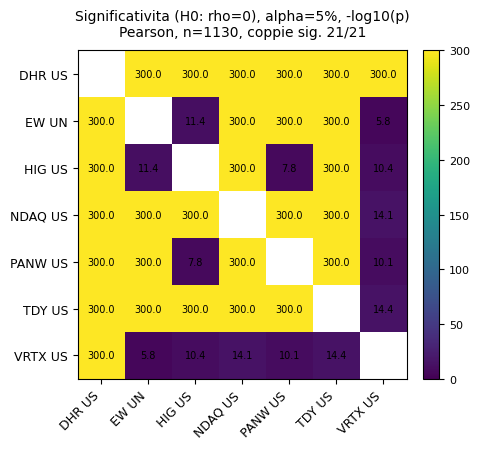

[SAVE] /content/figures/p2_correlations_report.pdf
[SAVE] /content/figures/p2_correlations_report.png


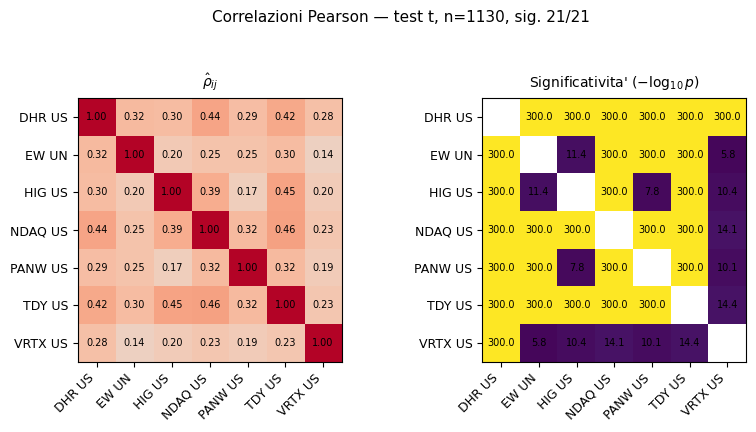

In [8]:
lbl = [short_ticker(c) for c in R.columns]

fig_r, ax_r = plt.subplots(figsize=(4.8, 4.2))
im_r = ax_r.imshow(R.values, vmin=-1, vmax=1, cmap="coolwarm")
ax_r.set_xticks(np.arange(len(lbl)))
ax_r.set_yticks(np.arange(len(lbl)))
ax_r.set_xticklabels(lbl, rotation=45, ha="right")
ax_r.set_yticklabels(lbl)
ax_r.set_title(f"$\\hat\\rho_{{ij}}$ (n={n_obs_lw})")
annotate_heatmap_cells(ax_r, R.values, fmt="{:.2f}", fontsize=7, color="black")
fig_r.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)
apply_report_style(fig_r)
fig_r.tight_layout(pad=1.0)
maybe_save(fig_r, "p2_corr_heatmap")
plt.show()
plt.close(fig_r)

Pv = P.values.astype(float).copy()
np.fill_diagonal(Pv, np.nan)
with np.errstate(divide="ignore", invalid="ignore"):
    Z = -np.log10(np.clip(Pv, 1e-300, 1.0))
np.fill_diagonal(Z, np.nan)
Z_plot = np.ma.masked_invalid(Z)
zcomp = Z_plot.compressed()
zmax = max(float(np.percentile(zcomp, 99)) if zcomp.size else 3.0, 3.0)

fig_p, ax_p = plt.subplots(figsize=(5.2, 4.6))
im_p = ax_p.imshow(Z_plot, cmap="viridis", vmin=0.0, vmax=zmax, aspect="equal")
ax_p.set_xticks(np.arange(len(lbl)))
ax_p.set_yticks(np.arange(len(lbl)))
ax_p.set_xticklabels(lbl, rotation=45, ha="right", fontsize=9)
ax_p.set_yticklabels(lbl, fontsize=9)
ax_p.set_title(
    f"Significativita (H0: rho=0), alpha={CORR_SIGNIFICANCE_ALPHA:.0%}, -log10(p)\n"
    f"Pearson, n={n_obs_lw}, coppie sig. {n_sig_pairs}/{n_pairs}",
    fontsize=10,
    pad=10,
)
annotate_heatmap_cells(ax_p, Z_plot, fmt="{:.1f}", fontsize=7, color="black", skip_diag=True)
fig_p.colorbar(im_p, ax=ax_p, fraction=0.046, pad=0.04)
apply_report_style(fig_p)
fig_p.tight_layout(pad=1.2)
maybe_save(fig_p, "p2_corr_pvalues_heatmap")
plt.show()
plt.close(fig_p)

if SAVE_P2_CORR_COMBINED:
    fig_both, (ax_br, ax_bp) = plt.subplots(1, 2, figsize=(9.0, 4.4))
    ax_br.imshow(R.values, vmin=-1, vmax=1, cmap="coolwarm")
    ax_br.set_xticks(np.arange(len(lbl)))
    ax_br.set_yticks(np.arange(len(lbl)))
    ax_br.set_xticklabels(lbl, rotation=45, ha="right", fontsize=9)
    ax_br.set_yticklabels(lbl, fontsize=9)
    ax_br.set_title(r"$\hat\rho_{ij}$", fontsize=10, pad=8)
    annotate_heatmap_cells(ax_br, R.values, fmt="{:.2f}", fontsize=7, color="black")
    ax_bp.imshow(Z_plot, cmap="viridis", vmin=0.0, vmax=zmax, aspect="equal")
    ax_bp.set_xticks(np.arange(len(lbl)))
    ax_bp.set_yticks(np.arange(len(lbl)))
    ax_bp.set_xticklabels(lbl, rotation=45, ha="right", fontsize=9)
    ax_bp.set_yticklabels(lbl, fontsize=9)
    ax_bp.set_title(r"Significativita' ($-\log_{10} p$)", fontsize=10, pad=8)
    annotate_heatmap_cells(ax_bp, Z_plot, fmt="{:.1f}", fontsize=7, color="black", skip_diag=True)
    fig_both.suptitle(
        f"Correlazioni Pearson — test t, n={n_obs_lw}, sig. {n_sig_pairs}/{n_pairs}",
        fontsize=11,
        y=1.02,
    )
    apply_report_style(fig_both)
    fig_both.subplots_adjust(bottom=0.22, top=0.82, wspace=0.38)
    maybe_save(fig_both, "p2_correlations_report")
    plt.show()
    plt.close(fig_both)


[SAVE] /content/figures/p2_vol_overlay_roll_ewma_garch_panels.pdf
[SAVE] /content/figures/p2_vol_overlay_roll_ewma_garch_panels.png


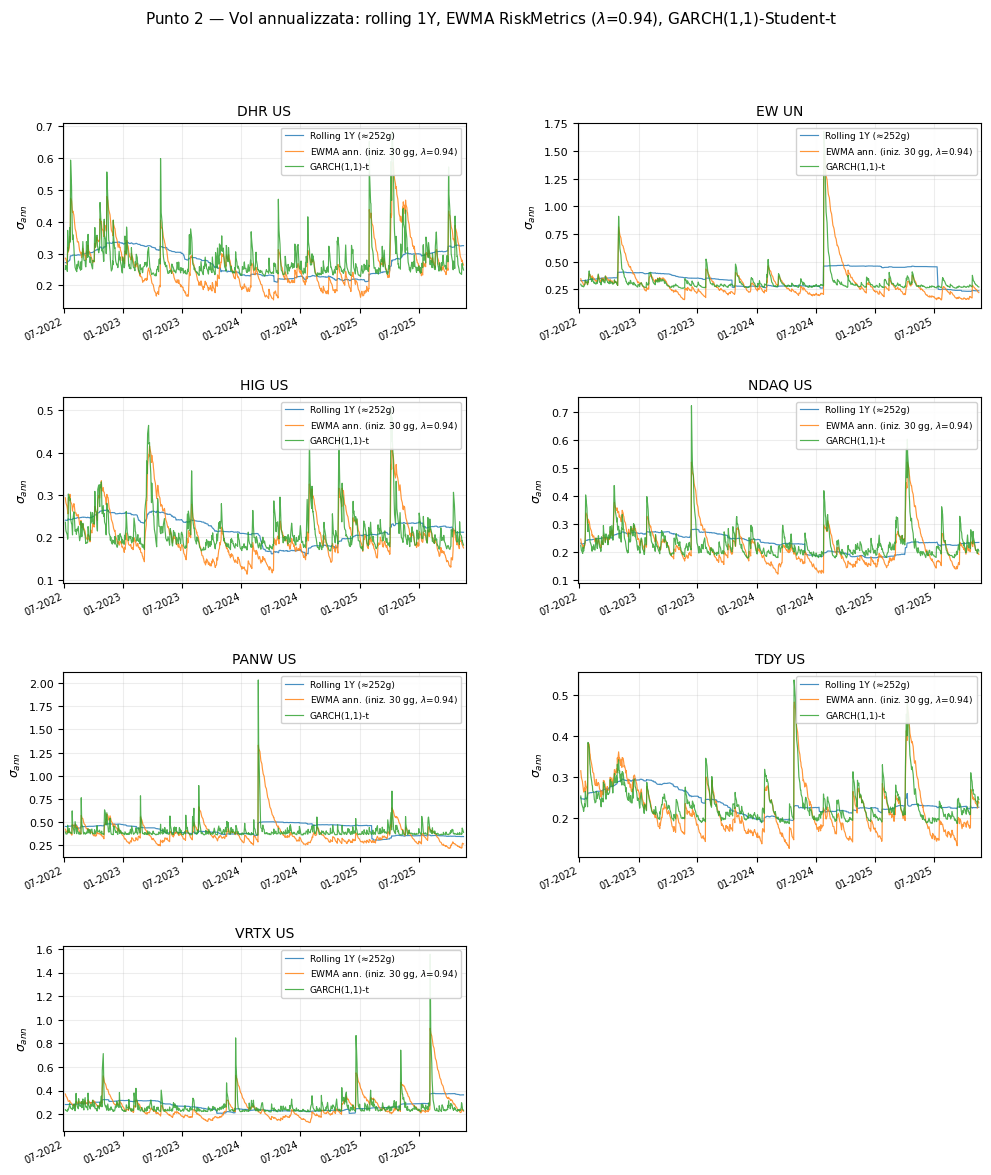

In [9]:
# Stile leggibile per report: pannelli un po' piu' grandi, linee sottili e semi-trasparenti
P2_VOL_PANEL_FIGSIZE = (10.2, 12.0)
P2_VOL_LINEWIDTH = 0.85
P2_VOL_LINE_ALPHA = 0.82

fig, axes = plt.subplots(4, 2, figsize=P2_VOL_PANEL_FIGSIZE, sharex=False)
axes = axes.ravel()

for ax_i, col in zip(axes, returns_log.columns):
    r1 = roll_ann_1y[col].dropna()
    e1 = ewma_vol_ann_df[col].reindex(r1.index).dropna()
    g1 = garch_vol_ann[col].reindex(r1.index).dropna()

    kw = {"linewidth": P2_VOL_LINEWIDTH, "alpha": P2_VOL_LINE_ALPHA}
    ax_i.plot(r1.index, r1.values, color="#1f77b4", label=f"Rolling {win_1y_name}", **kw)
    ax_i.plot(e1.index, e1.values, color="#ff7f0e", label=label_ewma_riskmetrics(), **kw)
    _model_label = garch_params_df.loc[col, "model"] if col in garch_params_df.index else "GARCH/EGARCH"
    ax_i.plot(g1.index, g1.values, color="#2ca02c", label=_model_label, **kw)

    ax_i.set_title(short_ticker(col), fontsize=10)
    ax_i.set_ylabel(r"$\sigma_{ann}$", fontsize=9)
    ax_i.grid(True, alpha=0.22)
    ax_i.legend(fontsize=6.5, loc="upper right", framealpha=0.9)

axes[-1].axis("off")
fig.suptitle(
    r"Punto 2 — Vol annualizzata: rolling 1Y, EWMA RiskMetrics ($\lambda$=0.94), GARCH(1,1)-Student-t",
    y=0.995,
    fontsize=11,
)

fig.subplots_adjust(left=0.08, right=0.98, top=0.90, bottom=0.06, hspace=0.48, wspace=0.28)
finalize_date_axes(axes[:-1], fig=fig, fontsize=7.0, rotation=25.0)

maybe_save(fig, "p2_vol_overlay_roll_ewma_garch_panels")
plt.show()
plt.close(fig)



=== Punto 3 — VaR (log-rendimenti; valore positivo = magnitudine perdita al quantile) ===
Parametri: ALPHA=0.05 (conf≈95%), H=1 giorni, MC_N=50000, seed=42, storico=quantile empirico (method='linear'), OOS split train_frac=0.5
Unità tabella `var_*`: magnitudine su log-rendimento (×100 ≈ % per |g| piccolo). VaR in USD: posizione long 100,000 USD per titolo; perdita al quantile ≈ notional × (1 - exp(-VaR_g)).


,var_parametric_pct,var_historical_pct,var_mc_gaussian_pct
ticker,,,
DHR US Equity,2.8847,2.7151,2.8924
EW UN Equity,3.6038,2.7305,3.5937
HIG US EQUITY,2.1964,2.1990,2.2019
NDAQ US EQUITY,2.3733,2.2936,2.3604
PANW US EQUITY,4.1865,3.7980,4.1737
TDY US EQUITY,2.4184,2.3111,2.4323
VRTX US Equity,2.8710,2.3530,2.8589


,var_parametric_usd,var_historical_usd,var_mc_gaussian_usd
ticker,,,
DHR US Equity,2843.50,2678.53,2850.98
EW UN Equity,3539.68,2693.54,3529.92
HIG US EQUITY,2172.42,2174.95,2177.84
NDAQ US EQUITY,2345.36,2267.49,2332.75
PANW US EQUITY,4100.12,3726.76,4087.82
TDY US EQUITY,2389.38,2284.59,2402.92
VRTX US Equity,2830.20,2325.54,2818.39



--- Snippet LaTeX (Punto 3) ---

\subsection*{Value-at-Risk (Punto 3)}
Si stima il VaR al livello $\alpha=0.05$ (coda sinistra) sui log-rendimenti giornalieri
$g_t=\ln(P_t/P_{t-1})$, con orizzonte $H=1$ giorno/i.
Il VaR e' riportato come magnitudine positiva di perdita: $\mathrm{VaR}_g=-Q_\alpha(g^{(H)})$,
dove $g^{(H)}$ e' il log-rendimento su $H$ giorni (per $H>1$: somma di $H$ incrementi consecutivi nello storico; nel parametrico/Monte Carlo gaussiano si assume i.i.d.\ con varianza scalata per $\sqrt{H}$ nel termine gaussiano).
Per una posizione long di nominale $M=100,000$ USD sul singolo titolo,
la perdita in valore semplice al quantile si ottiene da $\mathrm{VaR}_g$ con
$\mathrm{VaR}_{\mathrm{USD}}\approx M\bigl(1-\mathrm{e}^{-\mathrm{VaR}_g}\bigr)$
(per $|\mathrm{VaR}_g|\ll 1$: $\mathrm{VaR}_{\mathrm{USD}}\approx M\,\mathrm{VaR}_g$).
\textbf{Parametrico}: $Q_\alpha$ da normale con $\hat\mu,\hat\sigma$ campionari sui $g_t$.
\textbf{Storico}: quantile empirico (\texttt{linear}).


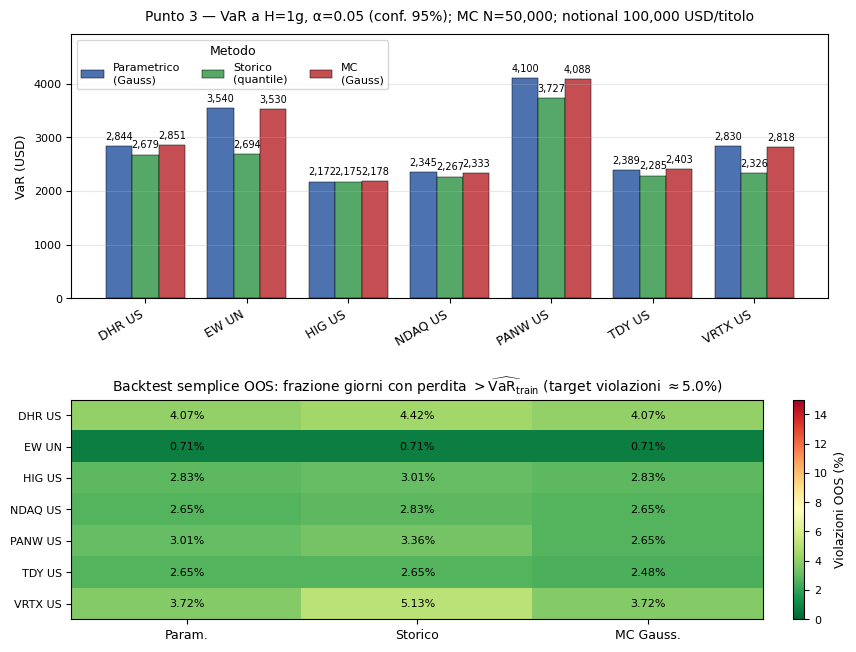

In [10]:
# =============================================================================
# PUNTO 3 — VaR (parametrico gaussiano, storico, MC gaussiano)
# NOTE consegna: alpha e orizzonte come PARAMETRI (non hardcoded nelle formule).
# Poche figure, dense: 1) barre VaR per tutti i titoli e metodi; 2) heatmap
#    violazioni out-of-sample (stima su prima meta campione, test su seconda).
# =============================================================================

# --- Parametri utente (modificabili; usati ovunque sotto) --------------------
VAR_ALPHA = 0.05  # coda sinistra sui rendimenti; VaR(95%) se interpretato così
VAR_HORIZON_DAYS = 1  # orizzonte in giorni (1 = VaR 1 giorno; >1: somma h log-ret i.i.d. in MC / rolling sum storico / sqrt-time gaussiano)
MC_N_SIMULATIONS = 50_000
MC_RANDOM_SEED = 42
# Storico: quantile empirico su rendimenti; se orizzonte>1 usa somme rolling h giorni
HIST_QUANTILE_METHOD = "linear"  # coerente con numpy 2.x

VAR_CONF_LEVEL = 1.0 - VAR_ALPHA  # solo per etichette / report

# Backtest semplice out-of-sample: stima VaR su prima frazione, violazioni sulla seconda
VAR_TRAIN_FRAC = 0.5

# Montante di riferimento (USD) per esposizione **per singolo titolo** nel reporting VaR:
# perdita monetaria al quantile ≈ notional * (1 - exp(-VaR_g)), con VaR_g = -Q_alpha sui log-rendimenti.
# Allineato al notional del punto 4.a (100k); modificabile indipendentemente.
VAR_REFERENCE_NOTIONAL_USD = 100_000.0


def _quantile_compat(a: np.ndarray | pd.Series, q: float) -> float:
    a = np.asarray(a, dtype=float)
    try:
        return float(np.quantile(a, q, method=HIST_QUANTILE_METHOD))
    except TypeError:
        return float(np.quantile(a, q, interpolation="linear"))


def _var_positive_loss_from_logret(
    g: pd.Series,
    *,
    alpha: float,
    horizon: int,
    method: str,
    rng: np.random.Generator | None = None,
    n_mc: int = MC_N_SIMULATIONS,
) -> float:
    """
    VaR (1 giorno o h giorni) come MAGNITUDINE POSITIVA di perdita sul log-rendimento
    (perdita se g << 0): VaR = -Q_alpha(g_h) dove Q e' il quantile empirico / teorico.
    """
    g = g.dropna().astype(float)
    if len(g) < max(30, horizon + 5):
        return float("nan")

    if horizon == 1:
        g_h = g
    else:
        g_h = g.rolling(horizon, min_periods=horizon).sum().dropna()

    if method == "parametric":
        mu = float(g.mean())  # su g a 1 giorno per stima mu,sigma daily
        sig = float(g.std(ddof=1))
        z = float(stats.norm.ppf(alpha))
        if horizon == 1:
            q = mu + sig * z
        else:
            q = horizon * mu + np.sqrt(horizon) * sig * z
        return float(-q)

    if method == "historical":
        q = _quantile_compat(g_h, alpha)
        return float(-q)

    if method == "mc_gaussian":
        if rng is None:
            rng = np.random.default_rng(MC_RANDOM_SEED)
        mu = float(g.mean())
        sig = float(g.std(ddof=1))
        if horizon == 1:
            sim = rng.normal(mu, sig, size=n_mc)
        else:
            sim = rng.normal(mu, sig, size=(n_mc, horizon)).sum(axis=1)
        q = _quantile_compat(sim, alpha)
        return float(-q)

    raise ValueError(method)


def _build_var_table(returns: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for j, col in enumerate(returns.columns):
        rng_j = np.random.default_rng(MC_RANDOM_SEED + j * 1009)
        s = returns[col]
        rows.append(
            {
                "ticker": col,
                "var_parametric": _var_positive_loss_from_logret(
                    s, alpha=VAR_ALPHA, horizon=VAR_HORIZON_DAYS, method="parametric"
                ),
                "var_historical": _var_positive_loss_from_logret(
                    s, alpha=VAR_ALPHA, horizon=VAR_HORIZON_DAYS, method="historical"
                ),
                "var_mc_gaussian": _var_positive_loss_from_logret(
                    s,
                    alpha=VAR_ALPHA,
                    horizon=VAR_HORIZON_DAYS,
                    method="mc_gaussian",
                    rng=rng_j,
                    n_mc=MC_N_SIMULATIONS,
                ),
            }
        )
    return pd.DataFrame(rows).set_index("ticker")


def var_logret_magnitude_to_usd_loss(var_mag: pd.DataFrame, notional_usd: float) -> pd.DataFrame:
    """Da VaR = -Q_alpha(g) (log-rend.) a perdita USD su posizione long di `notional_usd`."""
    x = var_mag.astype(float)
    return notional_usd * (1.0 - np.exp(-x))


def var_logret_mag_to_usd_loss_scalar(var_mag: float, notional_usd: float) -> float:
    if not np.isfinite(var_mag):
        return float("nan")
    return float(notional_usd * (1.0 - np.exp(-float(var_mag))))


def var_portfolio_parametric_gaussian(
    returns: pd.DataFrame,
    weights_equity: np.ndarray,
    *,
    alpha: float,
    horizon: int,
) -> tuple[float, float, float, pd.DataFrame, pd.DataFrame]:
    """
    VaR portafoglio (log-rend.) con approccio varianza-covarianza gaussiano (4.c).

    - Pesi w_i sulle azioni (somma = 1 - w_cash); liquidita' esclusa da Sigma (vol=0).
    - mu_p = w' mu, sigma_p = sqrt(w' Sigma w) sui log-rendimenti giornalieri azionari.
    - Coerente con allocazione 90% risky / 10% cash; NON ribilancia giornalmente.
    """
    x = returns.dropna(how="any").astype(float)
    if x.shape[0] < max(30, horizon + 5):
        return float("nan"), float("nan"), float("nan"), pd.DataFrame(), pd.DataFrame()

    w = np.asarray(weights_equity, dtype=float).reshape(-1)
    if w.shape[0] != x.shape[1]:
        raise ValueError("weights_equity e colonne returns non allineati.")

    mu_vec = x.mean().values
    cov_mat = x.cov(ddof=1)
    corr_mat = x.corr(method="pearson")

    mu_p = float(w @ mu_vec)
    sigma_p = float(np.sqrt(w @ cov_mat.values @ w))
    z = float(stats.norm.ppf(alpha))
    h = int(horizon)
    if h == 1:
        q_alpha = mu_p + sigma_p * z
    else:
        q_alpha = h * mu_p + np.sqrt(h) * sigma_p * z
    var_g = float(-q_alpha)
    return var_g, mu_p, sigma_p, cov_mat, corr_mat


def var_portfolio_parametric_custom_cov(
    returns: pd.DataFrame,
    weights_equity: np.ndarray,
    cov_matrix: pd.DataFrame | np.ndarray,
    *,
    alpha: float,
    horizon: int,
) -> tuple[float, float, float]:
    """VaR parametrico con Sigma fornita (es. diagonale = asset indipendenti, stesse marginali)."""
    x = returns.dropna(how="any").astype(float)
    w = np.asarray(weights_equity, dtype=float).reshape(-1)
    cov = np.asarray(cov_matrix, dtype=float)
    if cov.shape != (x.shape[1], x.shape[1]):
        raise ValueError("cov_matrix non coerente con il numero di titoli.")
    mu_vec = x.mean().values
    mu_p = float(w @ mu_vec)
    sigma_p = float(np.sqrt(w @ cov @ w))
    z = float(stats.norm.ppf(alpha))
    h = int(horizon)
    if h == 1:
        q_alpha = mu_p + sigma_p * z
    else:
        q_alpha = h * mu_p + np.sqrt(h) * sigma_p * z
    return float(-q_alpha), mu_p, sigma_p


def var_portfolio_mc_gaussian(
    returns: pd.DataFrame,
    weights_equity: np.ndarray,
    *,
    alpha: float,
    horizon: int,
    rng: np.random.Generator | None = None,
    n_mc: int = MC_N_SIMULATIONS,
) -> tuple[float, float, float]:
    """
    VaR portafoglio MC gaussiano (4.c), coerente con Punto 3.

    Simula rendimenti giornalieri multivariati g ~ N(mu_hat, Sigma_hat) sulle azioni,
    costruisce g_p = w' g (pesi azionari, somma = 1 - w_cash) e stima il quantile
    empirico al livello alpha (coda sinistra). Usa la stessa Sigma del parametrico.
    """
    x = returns.dropna(how="any").astype(float)
    if x.shape[0] < max(30, horizon + 5):
        return float("nan"), float("nan"), float("nan")

    w = np.asarray(weights_equity, dtype=float).reshape(-1)
    if w.shape[0] != x.shape[1]:
        raise ValueError("weights_equity e colonne returns non allineati.")

    mu_vec = x.mean().values
    cov_mat = x.cov(ddof=1).values
    # Stabilizzazione numerica se Sigma e' quasi singolare
    cov_mat = cov_mat + 1e-10 * np.eye(cov_mat.shape[0])

    if rng is None:
        rng = np.random.default_rng(MC_RANDOM_SEED + 9031)

    mu_p = float(w @ mu_vec)
    sigma_p = float(np.sqrt(w @ cov_mat @ w))
    h = int(horizon)

    if h == 1:
        sim = rng.multivariate_normal(mu_vec, cov_mat, size=n_mc)
        g_p = sim @ w
    else:
        g_p = np.zeros(n_mc, dtype=float)
        for _ in range(h):
            sim = rng.multivariate_normal(mu_vec, cov_mat, size=n_mc)
            g_p += sim @ w

    q = _quantile_compat(g_p, alpha)
    return float(-q), mu_p, sigma_p


def _corr_pairwise_summary(corr: pd.DataFrame) -> tuple[pd.Series, pd.DataFrame]:
    """Statistiche sulle coppie (i<j) e tabella delle coppie con |rho| piu' alto."""
    cols = list(corr.columns)
    rows = []
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            rows.append({"asset_i": cols[i], "asset_j": cols[j], "rho": float(corr.iloc[i, j])})
    pairs = pd.DataFrame(rows)
    if pairs.empty:
        stats = pd.Series(dtype=float)
        return stats, pairs
    pairs["abs_rho"] = pairs["rho"].abs()
    stats = pd.Series(
        {
            "n_pairs": len(pairs),
            "mean_rho": float(pairs["rho"].mean()),
            "mean_abs_rho": float(pairs["abs_rho"].mean()),
            "min_rho": float(pairs["rho"].min()),
            "max_rho": float(pairs["rho"].max()),
        }
    )
    top = pairs.sort_values("abs_rho", ascending=False).head(5)
    return stats, top


def _var_on_train(g: pd.Series, method: str, rng: np.random.Generator) -> float:
    g = g.dropna().astype(float)
    n = len(g)
    split = int(n * VAR_TRAIN_FRAC)
    g_train = g.iloc[:split]
    return _var_positive_loss_from_logret(g_train, alpha=VAR_ALPHA, horizon=VAR_HORIZON_DAYS, method=method, rng=rng)


def _exceedance_matrix(returns: pd.DataFrame) -> pd.DataFrame:
    M = pd.DataFrame(index=returns.columns, columns=["parametric", "historical", "mc_gaussian"], dtype=float)
    h = int(VAR_HORIZON_DAYS)
    for j, col in enumerate(returns.columns):
        rng_c = np.random.default_rng(MC_RANDOM_SEED + 17_000 + j)
        g = returns[col].dropna().astype(float)
        if len(g) < max(40, h + 10):
            M.loc[col, :] = np.nan
            continue
        split = int(len(g) * VAR_TRAIN_FRAC)
        g_tail = g.iloc[split:]
        if h == 1:
            loss_test = -g_tail
        else:
            sums = g.rolling(h, min_periods=h).sum()
            loss_test = -sums.iloc[split:].dropna()

        for meth, key in [
            ("parametric", "parametric"),
            ("historical", "historical"),
            ("mc_gaussian", "mc_gaussian"),
        ]:
            v_tr = _var_on_train(g, key, rng_c)
            M.loc[col, meth] = float((loss_test > v_tr).mean()) if len(loss_test) else np.nan
    return M


var_table = _build_var_table(returns_log)
var_table_usd = var_logret_magnitude_to_usd_loss(var_table, VAR_REFERENCE_NOTIONAL_USD)
print("\n=== Punto 3 — VaR (log-rendimenti; valore positivo = magnitudine perdita al quantile) ===")
print(
    f"Parametri: ALPHA={VAR_ALPHA} (conf≈{VAR_CONF_LEVEL:.0%}), "
    f"H={VAR_HORIZON_DAYS} giorni, MC_N={MC_N_SIMULATIONS}, seed={MC_RANDOM_SEED}, "
    f"storico=quantile empirico (method={HIST_QUANTILE_METHOD!r}), "
    f"OOS split train_frac={VAR_TRAIN_FRAC}"
)
print(
    f"Unità tabella `var_*`: magnitudine su log-rendimento (×100 ≈ % per |g| piccolo). "
    f"VaR in USD: posizione long {VAR_REFERENCE_NOTIONAL_USD:,.0f} USD per titolo; "
    f"perdita al quantile ≈ notional × (1 - exp(-VaR_g))."
)
display((var_table * 100).round(4).rename(columns=lambda c: c + "_pct"))
display(var_table_usd.round(2).rename(columns=lambda c: c + "_usd"))

exceed_mat = _exceedance_matrix(returns_log)

REPORT_PUNTO3_SNIPPET_LATEX = rf"""
\subsection*{{Value-at-Risk (Punto 3)}}
Si stima il VaR al livello $\alpha={VAR_ALPHA}$ (coda sinistra) sui log-rendimenti giornalieri
$g_t=\ln(P_t/P_{{t-1}})$, con orizzonte $H={VAR_HORIZON_DAYS}$ giorno/i.
Il VaR e' riportato come magnitudine positiva di perdita: $\mathrm{{VaR}}_g=-Q_\alpha(g^{{(H)}})$,
dove $g^{{(H)}}$ e' il log-rendimento su $H$ giorni (per $H>1$: somma di $H$ incrementi consecutivi nello storico; nel parametrico/Monte Carlo gaussiano si assume i.i.d.\ con varianza scalata per $\sqrt{{H}}$ nel termine gaussiano).
Per una posizione long di nominale $M={VAR_REFERENCE_NOTIONAL_USD:,.0f}$ USD sul singolo titolo,
la perdita in valore semplice al quantile si ottiene da $\mathrm{{VaR}}_g$ con
$\mathrm{{VaR}}_{{\mathrm{{USD}}}}\approx M\bigl(1-\mathrm{{e}}^{{-\mathrm{{VaR}}_g}}\bigr)$
(per $|\mathrm{{VaR}}_g|\ll 1$: $\mathrm{{VaR}}_{{\mathrm{{USD}}}}\approx M\,\mathrm{{VaR}}_g$).
\textbf{{Parametrico}}: $Q_\alpha$ da normale con $\hat\mu,\hat\sigma$ campionari sui $g_t$.
\textbf{{Storico}}: quantile empirico (\texttt{{{HIST_QUANTILE_METHOD}}}).
\textbf{{Monte Carlo}}: $N={MC_N_SIMULATIONS}$ simulazioni gaussiane (\texttt{{seed={MC_RANDOM_SEED}}}).
""".strip()

print("\n--- Snippet LaTeX (Punto 3) ---\n")
print(REPORT_PUNTO3_SNIPPET_LATEX)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        var_table.to_csv(os.path.join(FIG_DIR, "p3_var_table.csv"))
        var_table_usd.to_csv(os.path.join(FIG_DIR, "p3_var_table_usd.csv"))
        exceed_mat.to_csv(os.path.join(FIG_DIR, "p3_var_oos_exceedance.csv"))
        with open(os.path.join(FIG_DIR, "p3_report_snippet_var.tex"), "w", encoding="utf-8") as f:
            f.write("% --- Generato: VaR punto 3 ---\n\n")
            f.write(REPORT_PUNTO3_SNIPPET_LATEX + "\n")
        print(f"[SAVE] CSV/LaTeX Punto 3 in {os.path.abspath(FIG_DIR)}")
    except OSError as e:
        print(f"[SAVE] Punto 3 export fallito: {e}")

# --- Figura unica compatta: (A) VaR USD per titolo; (B) heatmap violazioni OOS ---
fig_p3, (ax_a, ax_b) = plt.subplots(
    2,
    1,
    figsize=(8.6, 6.8),
    gridspec_kw={"height_ratios": [1.2, 1.0], "hspace": 0.42},
)

methods = ["var_parametric", "var_historical", "var_mc_gaussian"]
labels_m = ["Parametrico\n(Gauss)", "Storico\n(quantile)", "MC\n(Gauss)"]
colors_m = ["#4C72B0", "#55A868", "#C44E52"]

x = np.arange(len(var_table))
w = 0.26
for i, (m, lab, c) in enumerate(zip(methods, labels_m, colors_m)):
    vals = var_table_usd[m].values.astype(float)
    bars = ax_a.bar(x + (i - 1) * w, vals, width=w, label=lab, color=c, edgecolor="black", linewidth=0.35)
    for b, val in zip(bars, vals):
        if np.isfinite(val):
            ax_a.text(
                b.get_x() + b.get_width() / 2.0,
                b.get_height() + 0.02 * (ax_a.get_ylim()[1] - ax_a.get_ylim()[0]),
                f"{val:,.0f}",
                ha="center",
                va="bottom",
                fontsize=7,
                rotation=0,
            )

tick_lbl_p3 = [short_ticker(t) for t in var_table.index]
ax_a.set_xticks(x)
ax_a.set_xticklabels(tick_lbl_p3, rotation=30, ha="right", fontsize=9)
ax_a.axhline(0.0, color="black", linewidth=0.6)
ax_a.set_ylabel("VaR (USD)")
ax_a.set_title(
    f"Punto 3 — VaR a H={VAR_HORIZON_DAYS}g, α={VAR_ALPHA} "
    f"(conf. {100 * VAR_CONF_LEVEL:.0f}%); MC N={MC_N_SIMULATIONS:,}; "
    f"notional {VAR_REFERENCE_NOTIONAL_USD:,.0f} USD/titolo",
    fontsize=10,
    pad=10,
)
ax_a.grid(True, axis="y", alpha=0.3)
ax_a.legend(title="Metodo", fontsize=8, title_fontsize=9, loc="upper left", ncol=3)
# Margine in alto per evitare che le etichette numeriche sulle barre tocchino la legenda
ymax_a = float(np.nanmax(var_table_usd.values))
ax_a.set_ylim(0.0, ymax_a * 1.20)

Z = (exceed_mat.values * 100.0).astype(float)
im = ax_b.imshow(Z, aspect="auto", cmap="RdYlGn_r", vmin=0.0, vmax=max(100 * VAR_ALPHA * 3, 0.15 * 100))
ax_b.set_xticks(np.arange(Z.shape[1]))
ax_b.set_yticks(np.arange(Z.shape[0]))
ax_b.set_xticklabels(["Param.", "Storico", "MC Gauss."], fontsize=9)
ax_b.set_yticklabels([short_ticker(t) for t in exceed_mat.index], fontsize=8)
ax_b.set_title(
    r"Backtest semplice OOS: frazione giorni con perdita $>\widehat{\mathrm{VaR}}_{\mathrm{train}}$ "
    rf"(target violazioni $\approx {100 * VAR_ALPHA:.1f}\%$)"
)
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        ax_b.text(j, i, f"{Z[i, j]:.2f}%", ha="center", va="center", fontsize=8, color="black")
cb = fig_p3.colorbar(im, ax=ax_b, fraction=0.046, pad=0.04)
cb.set_label("Violazioni OOS (%)")

apply_report_style(fig_p3)
fig_p3.subplots_adjust(left=0.08, right=0.96, top=0.96, bottom=0.10, hspace=0.45)
maybe_save(fig_p3, "p3_var_summary_and_oos_exceedance")
plt.show()



=== Punto 4.a — valore portafoglio (pesi costanti, liquidità 10%) ===
t0: 2022-11-17 00:00:00   t_end: 2025-11-17 00:00:00   osservazioni: 783


,ticker,peso
0,DHR US Equity,0.1
1,EW UN Equity,0.2
2,HIG US EQUITY,0.1
3,NDAQ US EQUITY,0.1
4,PANW US EQUITY,0.1
5,TDY US EQUITY,0.1
6,VRTX US Equity,0.2
7,Liquidità,0.1


[SAVE] /content/figures/p4a_portfolio_value_timeseries.csv
[SAVE] /content/figures/p4a_portfolio_constant_weights_3y.pdf
[SAVE] /content/figures/p4a_portfolio_constant_weights_3y.png


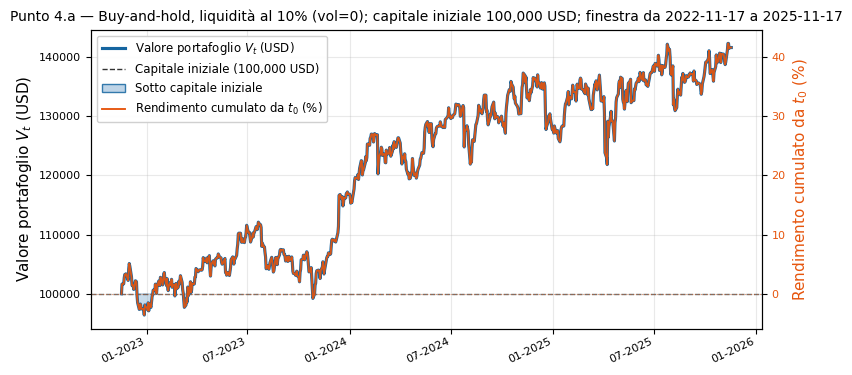


=== Punto 4.b — log-rendimenti portafoglio e volatilità (coerente con Punto 1–3) ===


,portafoglio
n_giorni_logret,782.000000
rendimento_totale_log,0.347713
rendimento_totale_simple,0.415826
media_giornaliera_log_ret,0.000445
vol_giornaliera_campione,0.009562
vol_ann_campione_sqrt252,0.151784
roll_window_giorni,21.000000


[SAVE] /content/figures/p4b_portfolio_log_returns_and_vol.csv
[SAVE] /content/figures/p4b_portfolio_log_returns_and_rolling_vol.pdf
[SAVE] /content/figures/p4b_portfolio_log_returns_and_rolling_vol.png


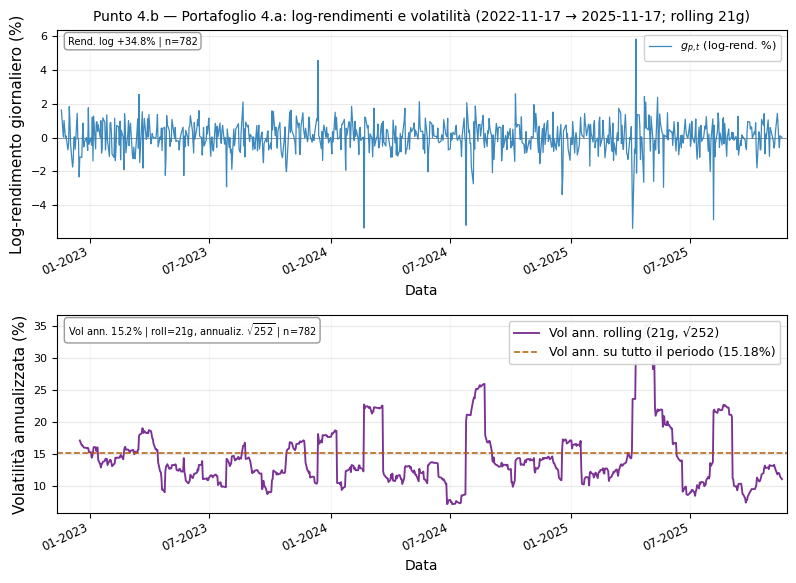


=== Punto 4.c — VaR portafoglio (USD) ===
Notional investitore N=100,000 USD | alpha=0.05 (conf.≈95%) | H=1g | pesi azioni (somma 90%) + liquidita' 10%
Parametrico: Sigma e correlazioni Pearson su log-rendimenti azionari, campione listwise n=783 (finestra da 2022-11-17).
Liquidita': NON inclusa in Sigma (rendimento nullo); riduce il rischio perche' solo il 90% del capitale e' esposto alle azioni tramite i pesi w_i.
Storico: quantile empirico su g_p = ln(V_t/V_{t-1}) del portafoglio 4.a (include implicitamente cash e non-linearita' del valore V).
Monte Carlo: 50,000 traiettorie gaussiane multivariate (stessa mu_hat, Sigma_hat del parametrico), g_p=w'g, seed=9073.


,var_g_log,var_usd,mu_p_giorno,sigma_p_giorno
parametrico_varcov,0.014779,1467.007381,0.000379,0.009215
montecarlo_mv_gauss,0.014788,1467.928637,0.000379,0.009215
storico_g_portafoglio,0.013473,1338.289194,NaN,NaN


Riferimento (non e' il VaR portafoglio corretto): sum_i w_i * VaR_USD_i^(Punto 3, 100k/titolo) ≈ 2,659 USD

--- Snippet LaTeX (Punto 4.c) ---

\subsection*{VaR portafoglio (Punto 4.c)}
Investimento $N=100,000$ USD, orizzonte $H=1$ giorno/i,
livello $\alpha=0.05$ (coda sinistra, confidenza nominale $95\%$).
Liquidita' al 10\%: rendimento nullo, non compare nella matrice di covarianza
(solo le 7 azioni, pesi che sommano al 90\%).
\textbf{Parametrico (varianza-covarianza)}: $\hat\Sigma$ e correlazioni di Pearson sui log-rendimenti
giornalieri (campione listwise $n=783$); $g_{p,t}\approx\sum_i w_i g_{i,t}$,
$\hat\mu_p=\mathbf{w}'\hat\mathbf{\mu}$, $\hat\sigma_p=\sqrt{\mathbf{w}'\hat\Sigma\mathbf{w}}$;
$\mathrm{VaR}_g=-(\hat\mu_p + z_\alpha\hat\sigma_p)$ (per $H>1$ scaling i.i.d.\ come Punto 3).
\textbf{Monte Carlo}: $N=50000$ simulazioni da $N(\hat\mathbf{\mu},\hat\Sigma)$, $g_p=\mathbf{w}'\mathbf{g}$,
quantile empirico al livello $\alpha$.
\textbf{Storico}: $\mathrm{VaR}_g=-Q_\alpha(g_p)$

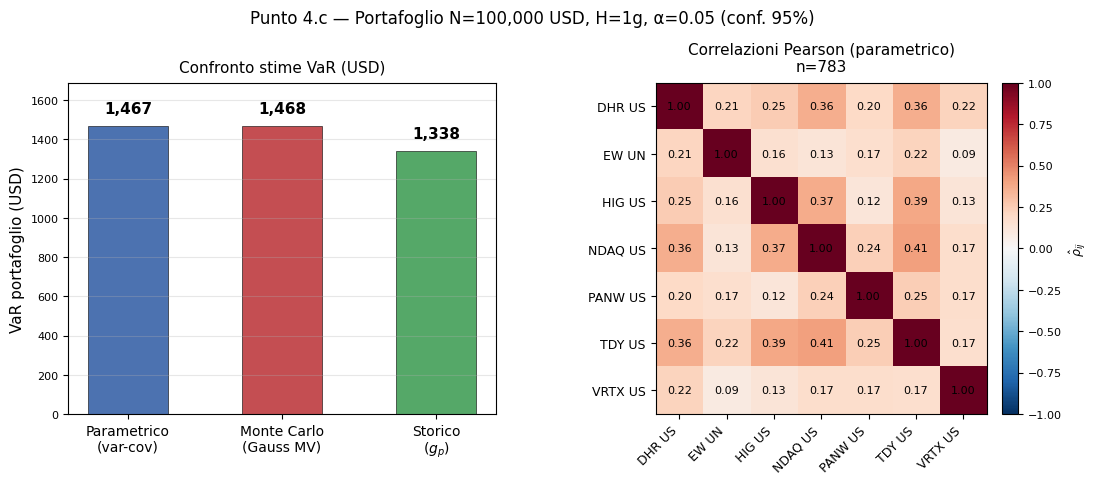


=== Punto 4.d — Correlazioni, diversificazione e link al VaR (4.c) ===
Campione: n=783 (listwise), liquidita' 10% fuori da Sigma.


,statistica
n_pairs,21.0000
mean_rho,0.2292
mean_abs_rho,0.2292
min_rho,0.0929
max_rho,0.4093


,asset_i,asset_j,rho,abs_rho
16,NDAQ US EQUITY,TDY US EQUITY,0.4093,0.4093
13,HIG US EQUITY,TDY US EQUITY,0.3872,0.3872
11,HIG US EQUITY,NDAQ US EQUITY,0.3726,0.3726
4,DHR US Equity,TDY US EQUITY,0.3649,0.3649
2,DHR US Equity,NDAQ US EQUITY,0.3642,0.3642


,valore
mean_rho_pairs,0.229216
mean_abs_rho_pairs,0.229216
max_rho_pairs,0.409334
min_rho_pairs,0.092892
sigma_p_daily_full_cov,0.009215
sigma_p_daily_diag_cov,0.006693
sigma_p_daily_w2_sigma2,0.006693
vol_diversification_ratio_1_minus_sigp_over_undiv,-0.376742
var_usd_parametric_sigma,1467.007381
var_usd_parametric_diag_rho0,1057.464727


,asset_i,asset_j,rho,p_value
0,DHR US Equity,EW UN Equity,0.2135,0.0000
1,DHR US Equity,HIG US EQUITY,0.2517,0.0000
2,DHR US Equity,NDAQ US EQUITY,0.3642,0.0000
3,DHR US Equity,PANW US EQUITY,0.1973,0.0000
4,DHR US Equity,TDY US EQUITY,0.3649,0.0000
5,DHR US Equity,VRTX US Equity,0.2250,0.0000
6,EW UN Equity,HIG US EQUITY,0.1573,0.0000
7,EW UN Equity,NDAQ US EQUITY,0.1251,0.0004
8,EW UN Equity,PANW US EQUITY,0.1715,0.0000
9,EW UN Equity,TDY US EQUITY,0.2246,0.0000



Giudizio sintetico:
 - Correlazioni medie (|rho|) moderate: diversificazione plausibile tra titoli.
 - Nel parametrico, la struttura di correlazione aumenta il VaR rispetto all'ipotesi indipendente.
 - Lo storico su g_p e' meno severo del parametrico sul campione considerato.

--- Snippet LaTeX (Punto 4.d) ---

\subsection*{Diversificazione e correlazioni (Punto 4.d)}
Matrice $\hat\mathbf{R}$ (Pearson) sui log-rendimenti azionari, $n=783$.
Media $|\hat\rho|$ sulle coppie: 0.229;
max $\hat\rho$: 0.409.
\textbf{VaR portafoglio (USD, $N=100,000$)}: parametrico con $\hat\Sigma$ = 1,467;
con $\hat\Sigma$ diagonale (stesse vol marginali, $\rho_{ij}=0$) = 1,057;
storico su $g_p$ = 1,338.
Riduzione VaR parametrico attribuibile alle correlazioni (vs indipendenti):
-410 USD (-38.7\%).
Riduzione vol portafoglio (vs $\sum_i w_i^2\sigma_i^2$): -37.7\% se applicabile.
[SAVE] CSV/LaTeX Punto 4.d in /content/figures
[SAVE] /content/figures/p4d_diversification_correlations_and_var_impact.pdf
[SAVE] /c

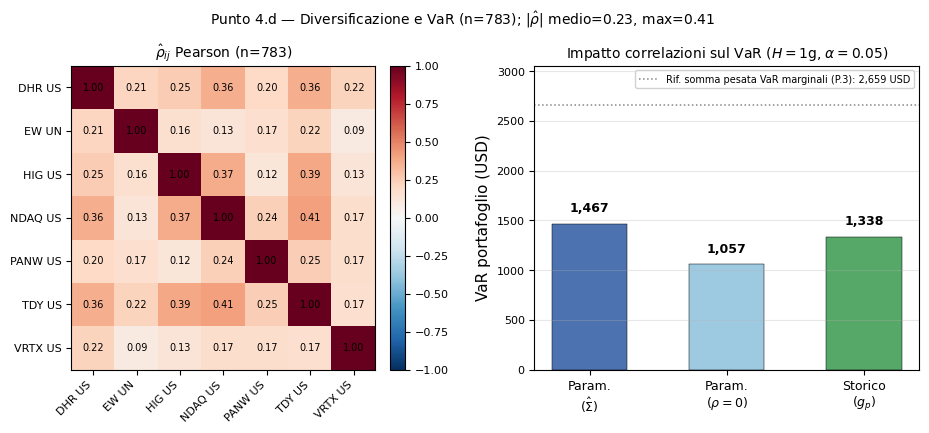

In [11]:
# =============================================================================
# PUNTO 4.a — Portafoglio a pesi costanti, investimento iniziale 100.000 USD,
#            ultimi 3 anni di storia (liquidità: 10%, vol=0, correlazione 0).
# =============================================================================

PORTFOLIO_NOTIONAL_USD = 100_000.0
PORTFOLIO_LOOKBACK_YEARS = 3

# Pesi: PORTFOLIO_WEIGHTS_BY_TICKER / PORTFOLIO_WEIGHTS_EQUITY (Punto 1)
if "PORTFOLIO_WEIGHTS_EQUITY" not in globals():
    PORTFOLIO_WEIGHTS_EQUITY = equity_weights_for_columns(prices.columns)

# Punto 4.b: finestra rolling (giorni di negoziazione) per vol. su g_p
PORTFOLIO_VOL_ROLL_WINDOW_DAYS = 21

assert np.isclose(float(PORTFOLIO_WEIGHTS_EQUITY.sum() + PORTFOLIO_WEIGHT_CASH), 1.0)
assert len(PORTFOLIO_WEIGHTS_EQUITY) == prices.shape[1]


def portfolio_value_constant_weights(
    prices_df: pd.DataFrame,
    w_eq: np.ndarray,
    w_cash: float,
    notional: float,
    lookback_years: int,
) -> tuple[pd.Series, pd.Timestamp, pd.Timestamp]:
    """
  4.a — Pesi costanti (consegna): allocazione iniziale buy-and-hold (non ribilanciamento giornaliero).

    V(t) = N * ( sum_i w_i * P_i(t)/P_i(t0) + w_cash ).
    Liquidita': rendimento nullo (10%), vol=0, correlazione 0 con le azioni.
    I rendimenti giornalieri del portafoglio in 4.b sono g_p = ln(V_t/V_{t-1}) coerenti con questa definizione.
    """
    end = prices_df.index.max()
    t0 = end - pd.DateOffset(years=lookback_years)
    sub = prices_df.loc[prices_df.index >= t0].copy().sort_index()
    sub = sub.ffill().dropna(how="all", axis=1)
    sub = sub.dropna()  # righe complete su tutti i titoli
    if sub.empty or len(sub) < 10:
        raise ValueError("Serie prezzi insufficienti per la finestra 3 anni.")

    t0_eff = sub.index[0]
    P0 = sub.iloc[0].astype(float)
    rel = sub.astype(float).div(P0, axis=1)
    w = pd.Series(w_eq, index=sub.columns)
    contrib = (rel.mul(w, axis=1)).sum(axis=1)
    V = notional * (contrib + w_cash)
    return V.rename("portfolio_value_usd"), t0_eff, sub.index.max()


V_pf, t0_pf, t_end_pf = portfolio_value_constant_weights(
    prices,
    PORTFOLIO_WEIGHTS_EQUITY,
    PORTFOLIO_WEIGHT_CASH,
    PORTFOLIO_NOTIONAL_USD,
    PORTFOLIO_LOOKBACK_YEARS,
)

print("\n=== Punto 4.a — valore portafoglio (pesi costanti, liquidità 10%) ===")
print("t0:", t0_pf, "  t_end:", t_end_pf, "  osservazioni:", len(V_pf))
w_tab = pd.concat(
    [
        pd.DataFrame({"ticker": list(prices.columns), "peso": PORTFOLIO_WEIGHTS_EQUITY}),
        pd.DataFrame({"ticker": ["Liquidità"], "peso": [PORTFOLIO_WEIGHT_CASH]}),
    ],
    ignore_index=True,
)
display(w_tab)

pct_from_start = (V_pf / V_pf.iloc[0] - 1.0) * 100.0
dd_pct = (V_pf / V_pf.cummax() - 1.0) * 100.0  # drawdown vs massimo progressivo

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        out = pd.DataFrame(
            {"V_usd": V_pf, "ret_pct_from_t0": pct_from_start, "drawdown_pct": dd_pct}
        )
        out.to_csv(os.path.join(FIG_DIR, "p4a_portfolio_value_timeseries.csv"))
        print(f"[SAVE] {os.path.join(FIG_DIR, 'p4a_portfolio_value_timeseries.csv')}")
    except OSError as e:
        print(f"[SAVE] CSV 4.a non salvato: {e}")

fig_p4a, ax_v = plt.subplots(figsize=(8.2, 3.8))
ax_r = ax_v.twinx()

# Colori distinti: linea $V_t$ ben visibile, area "sotto capitale" più chiara
_COLOR_V_LINE = "#1565a0"
_COLOR_V_FILL = "#b3cde3"
_COLOR_RET = "#e6550d"

ax_v.fill_between(
    V_pf.index,
    PORTFOLIO_NOTIONAL_USD,
    V_pf.values,
    where=V_pf.values < PORTFOLIO_NOTIONAL_USD,
    color=_COLOR_V_FILL,
    alpha=0.72,
    interpolate=True,
    zorder=1,
)
ax_v.plot(V_pf.index, V_pf.values, color=_COLOR_V_LINE, linewidth=2.25, zorder=3)
ax_v.axhline(
    PORTFOLIO_NOTIONAL_USD,
    color="#333333",
    linestyle="--",
    linewidth=1.0,
    alpha=0.65,
    zorder=2,
)

ax_r.plot(V_pf.index, pct_from_start.values, color=_COLOR_RET, linewidth=1.35, alpha=0.92, zorder=2)
ax_r.axhline(0.0, color=_COLOR_RET, linestyle=":", linewidth=0.8, alpha=0.5)

ax_v.set_ylabel("Valore portafoglio $V_t$ (USD)", fontsize=11)
ax_r.set_ylabel("Rendimento cumulato da $t_0$ (%)", fontsize=11, color=_COLOR_RET)
ax_r.tick_params(axis="y", labelcolor=_COLOR_RET)
ax_v.set_title(
    f"Punto 4.a — Buy-and-hold, liquidità al {100 * PORTFOLIO_WEIGHT_CASH:.0f}% (vol=0); "
    f"capitale iniziale {PORTFOLIO_NOTIONAL_USD:,.0f} USD; "
    f"finestra da {t0_pf.date()} a {t_end_pf.date()}"
)
ax_v.grid(True, alpha=0.28)
style_time_axis(ax_v)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

_legend_handles = [
    Line2D([0], [0], color=_COLOR_V_LINE, linewidth=2.25, label=r"Valore portafoglio $V_t$ (USD)"),
    Line2D(
        [0],
        [0],
        color="#333333",
        linestyle="--",
        linewidth=1.0,
        label=f"Capitale iniziale ({PORTFOLIO_NOTIONAL_USD:,.0f} USD)",
    ),
    Patch(
        facecolor=_COLOR_V_FILL,
        edgecolor=_COLOR_V_LINE,
        alpha=0.85,
        label="Sotto capitale iniziale",
    ),
    Line2D(
        [0],
        [0],
        color=_COLOR_RET,
        linewidth=1.35,
        label=r"Rendimento cumulato da $t_0$ (%)",
    ),
]
ax_v.legend(handles=_legend_handles, loc="upper left", fontsize=8.5, framealpha=0.92)

fig_p4a.tight_layout(pad=1.0)
maybe_save(fig_p4a, "p4a_portfolio_constant_weights_3y")
plt.show()

plt.close(fig_p4a)


# =============================================================================
# PUNTO 4.b — Log-rendimenti giornalieri del portafoglio, vol rolling e sintesi
#            su tutta la finestra 4.a (una figura compatta a 2 pannelli).
# =============================================================================

g_pf = np.log(V_pf / V_pf.shift(1)).dropna().astype(float)
g_pf.name = "log_return_1d"

vol_roll_ann = g_pf.rolling(PORTFOLIO_VOL_ROLL_WINDOW_DAYS, min_periods=PORTFOLIO_VOL_ROLL_WINDOW_DAYS).std(
    ddof=1
) * np.sqrt(252.0)

sigma_g_pf = float(g_pf.std(ddof=1))
sigma_ann_full = sigma_g_pf * np.sqrt(252.0)
mu_g_pf = float(g_pf.mean())

v0_pf, vT_pf = float(V_pf.iloc[0]), float(V_pf.iloc[-1])
ret_tot_log = float(np.log(vT_pf / v0_pf))
ret_tot_simple = float(vT_pf / v0_pf - 1.0)
n_obs_g = int(g_pf.shape[0])

summary_p4b = pd.Series(
    {
        "n_giorni_logret": n_obs_g,
        "rendimento_totale_log": ret_tot_log,
        "rendimento_totale_simple": ret_tot_simple,
        "media_giornaliera_log_ret": mu_g_pf,
        "vol_giornaliera_campione": sigma_g_pf,
        "vol_ann_campione_sqrt252": sigma_ann_full,
        "roll_window_giorni": PORTFOLIO_VOL_ROLL_WINDOW_DAYS,
    }
)

print("\n=== Punto 4.b — log-rendimenti portafoglio e volatilità (coerente con Punto 1–3) ===")
display(summary_p4b.to_frame("portafoglio"))

p4b_out = pd.DataFrame(
    {
        "V_usd": V_pf.reindex(g_pf.index),
        "g_log": g_pf,
        "g_log_pct": g_pf * 100.0,
        "vol_roll_ann": vol_roll_ann,
        "vol_roll_ann_pct": vol_roll_ann * 100.0,
    }
).sort_index()

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        p4b_out.to_csv(os.path.join(FIG_DIR, "p4b_portfolio_log_returns_and_vol.csv"))
        summary_p4b.to_csv(os.path.join(FIG_DIR, "p4b_portfolio_summary_stats.csv"))
        print(f"[SAVE] {os.path.join(FIG_DIR, 'p4b_portfolio_log_returns_and_vol.csv')}")
    except OSError as e:
        print(f"[SAVE] CSV 4.b non salvato: {e}")

fig_p4b, (ax_g, ax_sv) = plt.subplots(
    2,
    1,
    figsize=(8.2, 6.2),
    sharex=False,
    gridspec_kw={"height_ratios": [1.05, 1.0], "hspace": 0.38},
)

ax_g.axhline(0.0, color="black", linewidth=0.75, alpha=0.35)
ax_g.plot(g_pf.index, g_pf.values * 100.0, color="#2c7fb8", linewidth=0.9, alpha=0.92, label=r"$g_{p,t}$ (log-rend. %)")
ax_g.set_ylabel("Log-rendimento giornaliero (%)", fontsize=11)
ax_g.set_title(
    f"Punto 4.b — Portafoglio 4.a: log-rendimenti e volatilità ({t0_pf.date()} → {t_end_pf.date()}; "
    f"rolling {PORTFOLIO_VOL_ROLL_WINDOW_DAYS}g)"
)
ax_g.grid(True, axis="y", alpha=0.28)
ax_g.grid(True, axis="x", alpha=0.12)

ax_sv.plot(
    vol_roll_ann.index,
    vol_roll_ann.values * 100.0,
    color="#7b3294",
    linewidth=1.35,
    label=f"Vol ann. rolling ({PORTFOLIO_VOL_ROLL_WINDOW_DAYS}g, √252)",
)
ax_sv.axhline(
    sigma_ann_full * 100.0,
    color="#b35806",
    linestyle="--",
    linewidth=1.15,
    alpha=0.95,
    label=f"Vol ann. su tutto il periodo ({sigma_ann_full * 100:.2f}%)",
)
ax_sv.set_ylabel("Volatilità annualizzata (%)", fontsize=11)
ax_sv.set_xlabel("Data", fontsize=10)
ax_sv.grid(True, axis="y", alpha=0.28)
ax_sv.grid(True, axis="x", alpha=0.12)
ax_sv.legend(loc="upper right", fontsize=9, framealpha=0.94)

stats_txt_g = f"Rend. log {ret_tot_log * 100:+.1f}% | n={n_obs_g}"
ax_g.text(
    0.015,
    0.97,
    stats_txt_g,
    transform=ax_g.transAxes,
    fontsize=7.0,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.88, edgecolor="0.55"),
)

stats_txt_vol = (
    f"Vol ann. {sigma_ann_full * 100:.1f}% | roll={PORTFOLIO_VOL_ROLL_WINDOW_DAYS}g, "
    f"annualiz. $\\sqrt{{252}}$ | n={n_obs_g}"
)
ax_sv.text(
    0.015,
    0.97,
    stats_txt_vol,
    transform=ax_sv.transAxes,
    fontsize=7.0,
    va="top",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.88, edgecolor="0.55"),
)

ax_g.legend(loc="upper right", fontsize=8, framealpha=0.92)

fig_p4b.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.14, hspace=0.42)
finalize_date_axes((ax_g, ax_sv), g_pf.index, fontsize=8.5, rotation=25.0)
ax_g.set_xlabel("Data", fontsize=10)
ax_sv.set_xlabel("Data", fontsize=10)

maybe_save(fig_p4b, "p4b_portfolio_log_returns_and_rolling_vol")
plt.show()
plt.close(fig_p4b)


# =============================================================================
# PUNTO 4.c — VaR del portafoglio (investitore in USD): parametrico (Sigma, Pearson)
#            + simulazione storica su g_p del 4.b. Liquidita': fuori da Sigma (vol=0).
# =============================================================================

# Campione allineato sulla finestra del portafoglio 4.a (stesse date di V_pf)
returns_pf_window = returns_log.loc[returns_log.index >= t0_pf].dropna(how="any")
n_obs_var_pf = int(returns_pf_window.shape[0])

var_g_pf_hist = _var_positive_loss_from_logret(
    g_pf,
    alpha=VAR_ALPHA,
    horizon=VAR_HORIZON_DAYS,
    method="historical",
)

var_g_pf_param, mu_p_param, sigma_p_param, cov_pf_used, corr_pf_used = var_portfolio_parametric_gaussian(
    returns_pf_window,
    PORTFOLIO_WEIGHTS_EQUITY,
    alpha=VAR_ALPHA,
    horizon=VAR_HORIZON_DAYS,
)

var_usd_hist = var_logret_mag_to_usd_loss_scalar(var_g_pf_hist, PORTFOLIO_NOTIONAL_USD)
var_usd_param = var_logret_mag_to_usd_loss_scalar(var_g_pf_param, PORTFOLIO_NOTIONAL_USD)

_rng_pf_mc = np.random.default_rng(MC_RANDOM_SEED + 9031)
var_g_pf_mc, mu_p_mc, sigma_p_mc = var_portfolio_mc_gaussian(
    returns_pf_window,
    PORTFOLIO_WEIGHTS_EQUITY,
    alpha=VAR_ALPHA,
    horizon=VAR_HORIZON_DAYS,
    rng=_rng_pf_mc,
    n_mc=MC_N_SIMULATIONS,
)
var_usd_mc = var_logret_mag_to_usd_loss_scalar(var_g_pf_mc, PORTFOLIO_NOTIONAL_USD)

# Riferimento (solo confronto): somma pesata dei VaR marginali Punto 3 (100k/titolo ciascuno)
var_g_marg = var_table["var_parametric"].reindex(returns_pf_window.columns)
var_usd_marg_each = PORTFOLIO_NOTIONAL_USD * (1.0 - np.exp(-var_g_marg.astype(float)))
var_usd_naive_sum = float((PORTFOLIO_WEIGHTS_EQUITY * var_usd_marg_each.values).sum())

var_pf_table = pd.DataFrame(
    {
        "var_g_log": [var_g_pf_param, var_g_pf_mc, var_g_pf_hist],
        "var_usd": [var_usd_param, var_usd_mc, var_usd_hist],
        "mu_p_giorno": [mu_p_param, mu_p_mc, np.nan],
        "sigma_p_giorno": [sigma_p_param, sigma_p_mc, np.nan],
    },
    index=["parametrico_varcov", "montecarlo_mv_gauss", "storico_g_portafoglio"],
)

print("\n=== Punto 4.c — VaR portafoglio (USD) ===")
print(
    f"Notional investitore N={PORTFOLIO_NOTIONAL_USD:,.0f} USD | "
    f"alpha={VAR_ALPHA} (conf.≈{VAR_CONF_LEVEL:.0%}) | H={VAR_HORIZON_DAYS}g | "
    f"pesi azioni (somma {PORTFOLIO_WEIGHTS_EQUITY.sum():.0%}) + liquidita' {PORTFOLIO_WEIGHT_CASH:.0%}"
)
print(
    f"Parametrico: Sigma e correlazioni Pearson su log-rendimenti azionari, "
    f"campione listwise n={n_obs_var_pf} (finestra da {t0_pf.date()})."
)
print(
    "Liquidita': NON inclusa in Sigma (rendimento nullo); riduce il rischio perche' "
    "solo il 90% del capitale e' esposto alle azioni tramite i pesi w_i."
)
print(
    f"Storico: quantile empirico su g_p = ln(V_t/V_{{t-1}}) del portafoglio 4.a "
    f"(include implicitamente cash e non-linearita' del valore V)."
)
print(
    f"Monte Carlo: {MC_N_SIMULATIONS:,} traiettorie gaussiane multivariate "
    f"(stessa mu_hat, Sigma_hat del parametrico), g_p=w'g, seed={MC_RANDOM_SEED + 9031}."
)
display(var_pf_table.round(6))
if np.isfinite(var_usd_naive_sum):
    print(
        f"Riferimento (non e' il VaR portafoglio corretto): "
        f"sum_i w_i * VaR_USD_i^(Punto 3, 100k/titolo) ≈ {var_usd_naive_sum:,.0f} USD"
    )

REPORT_PUNTO4C_SNIPPET_LATEX = rf"""
\subsection*{{VaR portafoglio (Punto 4.c)}}
Investimento $N={PORTFOLIO_NOTIONAL_USD:,.0f}$ USD, orizzonte $H={VAR_HORIZON_DAYS}$ giorno/i,
livello $\alpha={VAR_ALPHA}$ (coda sinistra, confidenza nominale ${100 * VAR_CONF_LEVEL:.0f}\%$).
Liquidita' al {100 * PORTFOLIO_WEIGHT_CASH:.0f}\%: rendimento nullo, non compare nella matrice di covarianza
(solo le {len(PORTFOLIO_WEIGHTS_EQUITY)} azioni, pesi che sommano al {100 * PORTFOLIO_WEIGHTS_EQUITY.sum():.0f}\%).
\textbf{{Parametrico (varianza-covarianza)}}: $\hat\Sigma$ e correlazioni di Pearson sui log-rendimenti
giornalieri (campione listwise $n={n_obs_var_pf}$); $g_{{p,t}}\approx\sum_i w_i g_{{i,t}}$,
$\hat\mu_p=\mathbf{{w}}'\hat\mathbf{{\mu}}$, $\hat\sigma_p=\sqrt{{\mathbf{{w}}'\hat\Sigma\mathbf{{w}}}}$;
$\mathrm{{VaR}}_g=-(\hat\mu_p + z_\alpha\hat\sigma_p)$ (per $H>1$ scaling i.i.d.\ come Punto 3).
\textbf{{Monte Carlo}}: $N={MC_N_SIMULATIONS}$ simulazioni da $N(\hat\mathbf{{\mu}},\hat\Sigma)$, $g_p=\mathbf{{w}}'\mathbf{{g}}$,
quantile empirico al livello $\alpha$.
\textbf{{Storico}}: $\mathrm{{VaR}}_g=-Q_\alpha(g_p)$ con $g_p=\ln(V_t/V_{{t-1}})$ dal portafoglio 4.a.
Perdita USD: $\mathrm{{VaR}}_{{\mathrm{{USD}}}}\approx N(1-e^{{- \mathrm{{VaR}}_g}})$.
""".strip()

print("\n--- Snippet LaTeX (Punto 4.c) ---\n")
print(REPORT_PUNTO4C_SNIPPET_LATEX)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        var_pf_table.to_csv(os.path.join(FIG_DIR, "p4c_portfolio_var_table.csv"))
        cov_pf_used.to_csv(os.path.join(FIG_DIR, "p4c_portfolio_covariance_used.csv"))
        corr_pf_used.to_csv(os.path.join(FIG_DIR, "p4c_portfolio_correlation_pearson_used.csv"))
        with open(os.path.join(FIG_DIR, "p4c_report_snippet_var_portfolio.tex"), "w", encoding="utf-8") as f:
            f.write("% --- Generato: VaR portafoglio punto 4.c ---\n\n")
            f.write(REPORT_PUNTO4C_SNIPPET_LATEX + "\n")
        print(f"[SAVE] CSV/LaTeX Punto 4.c in {os.path.abspath(FIG_DIR)}")
    except OSError as e:
        print(f"[SAVE] Punto 4.c export fallito: {e}")

# Figura: VaR portafoglio USD + heatmap correlazioni (layout ampio, senza box testo)
fig_p4c, (ax_b, ax_c) = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.6),
    gridspec_kw={"width_ratios": [1.15, 1.0], "wspace": 0.38},
)

methods_p4c = ["Parametrico\n(var-cov)", "Monte Carlo\n(Gauss MV)", "Storico\n($g_p$)"]
vals_usd = [var_usd_param, var_usd_mc, var_usd_hist]
colors_p4c = ["#4C72B0", "#C44E52", "#55A868"]
x_p4c = np.arange(len(methods_p4c))
y_top = max((v for v in vals_usd if np.isfinite(v)), default=1.0) * 1.15
bars = ax_b.bar(x_p4c, vals_usd, width=0.52, color=colors_p4c, edgecolor="black", linewidth=0.4)
for b, val in zip(bars, vals_usd):
    if np.isfinite(val):
        ax_b.text(
            b.get_x() + b.get_width() / 2.0,
            b.get_height() + 0.03 * y_top,
            f"{val:,.0f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
        )
ax_b.set_ylim(0.0, y_top)
ax_b.set_xticks(x_p4c)
ax_b.set_xticklabels(methods_p4c, fontsize=10)
ax_b.set_ylabel("VaR portafoglio (USD)", fontsize=11)
ax_b.set_title("Confronto stime VaR (USD)", fontsize=11, pad=8)
ax_b.grid(True, axis="y", alpha=0.3)

C = corr_pf_used.values.astype(float) if not corr_pf_used.empty else np.eye(len(prices.columns))
im = ax_c.imshow(C, aspect="equal", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
ax_c.set_xticks(np.arange(C.shape[1]))
ax_c.set_yticks(np.arange(C.shape[0]))
short_lbl_p4c = [short_ticker(c) for c in corr_pf_used.columns]
ax_c.set_xticklabels(short_lbl_p4c, rotation=45, ha="right", fontsize=9)
ax_c.set_yticklabels(short_lbl_p4c, fontsize=9)
ax_c.set_title(f"Correlazioni Pearson (parametrico)\nn={n_obs_var_pf}", fontsize=11, pad=8)
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax_c.text(j, i, f"{C[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")
cb_p4c = fig_p4c.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)
cb_p4c.set_label(r"$\hat\rho_{ij}$")

fig_p4c.suptitle(
    f"Punto 4.c — Portafoglio N={PORTFOLIO_NOTIONAL_USD:,.0f} USD, "
    f"H={VAR_HORIZON_DAYS}g, α={VAR_ALPHA} "
    f"(conf. {100 * VAR_CONF_LEVEL:.0f}%)",
    fontsize=12,
    y=1.02,
)
apply_report_style(fig_p4c)
fig_p4c.subplots_adjust(left=0.07, right=0.95, top=0.86, bottom=0.14, wspace=0.40)
maybe_save(fig_p4c, "p4c_portfolio_var_usd_and_correlations")
plt.show()
plt.close(fig_p4c)

# =============================================================================
# PUNTO 4.d — Diversificazione (correlazioni) e impatto sul VaR portafoglio (4.c)
# =============================================================================

R_pf, P_pf, _, _ = corr_and_pvalues(
    returns_pf_window, alpha=CORR_SIGNIFICANCE_ALPHA
)
corr_stats, corr_top_pairs = _corr_pairwise_summary(corr_pf_used)

cov_diag_only = pd.DataFrame(
    np.diag(np.diag(cov_pf_used.values)),
    index=cov_pf_used.index,
    columns=cov_pf_used.columns,
)

var_g_pf_param_indep, mu_p_indep, sigma_p_indep = var_portfolio_parametric_custom_cov(
    returns_pf_window,
    PORTFOLIO_WEIGHTS_EQUITY,
    cov_diag_only,
    alpha=VAR_ALPHA,
    horizon=VAR_HORIZON_DAYS,
)
var_usd_param_indep = var_logret_mag_to_usd_loss_scalar(var_g_pf_param_indep, PORTFOLIO_NOTIONAL_USD)

w_eq = np.asarray(PORTFOLIO_WEIGHTS_EQUITY, dtype=float)
sig_i = np.sqrt(np.diag(cov_pf_used.values))
sigma_p_undiv = float(np.sum(w_eq * sig_i))
vol_div_ratio = 1.0 - sigma_p_param / sigma_p_undiv if sigma_p_undiv > 0 else np.nan

var_usd_reduction_corr = var_usd_param_indep - var_usd_param
var_usd_reduction_corr_pct = (
    100.0 * var_usd_reduction_corr / var_usd_param_indep if var_usd_param_indep > 0 else np.nan
)

# Coppie con correlazione significativa (H0: rho=0), se disponibile P_pf
sig_pairs = []
cols_pf = list(corr_pf_used.columns)
for i in range(len(cols_pf)):
    for j in range(i + 1, len(cols_pf)):
        p_ij = P_pf.loc[cols_pf[i], cols_pf[j]]
        if np.isfinite(p_ij) and p_ij < CORR_SIGNIFICANCE_ALPHA:
            sig_pairs.append(
                {
                    "asset_i": cols_pf[i],
                    "asset_j": cols_pf[j],
                    "rho": float(corr_pf_used.iloc[i, j]),
                    "p_value": float(p_ij),
                }
            )
sig_pairs_df = pd.DataFrame(sig_pairs)

judgment_it = []
if np.isfinite(corr_stats.get("mean_abs_rho", np.nan)):
    if corr_stats["mean_abs_rho"] < 0.45:
        judgment_it.append("Correlazioni medie (|rho|) moderate: diversificazione plausibile tra titoli.")
    elif corr_stats["mean_abs_rho"] < 0.65:
        judgment_it.append("Correlazioni medie non basse: diversificazione parziale.")
    else:
        judgment_it.append("Correlazioni medie elevate: beneficio diversificazione limitato.")
if np.isfinite(var_usd_reduction_corr) and var_usd_reduction_corr > 0:
    judgment_it.append(
        f"Nel parametrico, le correlazioni stimate riducono il VaR di circa "
        f"{var_usd_reduction_corr:,.0f} USD ({var_usd_reduction_corr_pct:.1f}% vs asset indipendenti)."
    )
elif np.isfinite(var_usd_reduction_corr) and var_usd_reduction_corr < 0:
    judgment_it.append(
        "Nel parametrico, la struttura di correlazione aumenta il VaR rispetto all'ipotesi indipendente."
    )
if np.isfinite(var_usd_hist) and np.isfinite(var_usd_param):
    if var_usd_hist > var_usd_param * 1.05:
        judgment_it.append(
            "Lo storico su g_p e' piu' severo del gaussiano (code/regimi oltre la Sigma media)."
        )
    elif var_usd_hist < var_usd_param * 0.95:
        judgment_it.append("Lo storico su g_p e' meno severo del parametrico sul campione considerato.")
    else:
        judgment_it.append("Storico e parametrico (Sigma) sono allineati in ordine di grandezza sul VaR USD.")

p4d_summary = pd.DataFrame(
    {
        "valore": [
            corr_stats.get("mean_rho", np.nan),
            corr_stats.get("mean_abs_rho", np.nan),
            corr_stats.get("max_rho", np.nan),
            corr_stats.get("min_rho", np.nan),
            sigma_p_param,
            sigma_p_indep,
            sigma_p_undiv,
            vol_div_ratio,
            var_usd_param,
            var_usd_param_indep,
            var_usd_hist,
            var_usd_naive_sum,
            var_usd_reduction_corr,
            var_usd_reduction_corr_pct,
            len(sig_pairs_df),
        ]
    },
    index=[
        "mean_rho_pairs",
        "mean_abs_rho_pairs",
        "max_rho_pairs",
        "min_rho_pairs",
        "sigma_p_daily_full_cov",
        "sigma_p_daily_diag_cov",
        "sigma_p_daily_sum_wi_sigmai",
        "vol_diversification_ratio_1_minus_sigp_over_undiv",
        "var_usd_parametric_sigma",
        "var_usd_parametric_diag_rho0",
        "var_usd_historical_gp",
        "var_usd_ref_sum_w_marginal_p3",
        "var_usd_benefit_corr_param_minus_indep",
        "var_usd_benefit_corr_pct",
        "n_sig_pairs_p05",
    ],
)

print("\n=== Punto 4.d — Correlazioni, diversificazione e link al VaR (4.c) ===")
print(f"Campione: n={n_obs_var_pf} (listwise), liquidita' {PORTFOLIO_WEIGHT_CASH:.0%} fuori da Sigma.")
display(corr_stats.to_frame("statistica").round(4))
display(corr_top_pairs.round(4))
display(p4d_summary.round(6))
if not sig_pairs_df.empty:
    display(sig_pairs_df.round(4))
print("\nGiudizio sintetico:")
for line in judgment_it:
    print(" -", line)

REPORT_PUNTO4D_SNIPPET_LATEX = rf"""
\subsection*{{Diversificazione e correlazioni (Punto 4.d)}}
Matrice $\hat\mathbf{{R}}$ (Pearson) sui log-rendimenti azionari, $n={n_obs_var_pf}$.
Media $|\hat\rho|$ sulle coppie: {corr_stats.get("mean_abs_rho", float("nan")):.3f};
max $\hat\rho$: {corr_stats.get("max_rho", float("nan")):.3f}.
\textbf{{VaR portafoglio (USD, $N={PORTFOLIO_NOTIONAL_USD:,.0f}$)}}: parametrico con $\hat\Sigma$ = {var_usd_param:,.0f};
con $\hat\Sigma$ diagonale (stesse vol marginali, $\rho_{{ij}}=0$) = {var_usd_param_indep:,.0f};
storico su $g_p$ = {var_usd_hist:,.0f}.
Riduzione VaR parametrico attribuibile alle correlazioni (vs indipendenti):
{var_usd_reduction_corr:,.0f} USD ({var_usd_reduction_corr_pct:.1f}\%).
Riduzione vol portafoglio (vs $\sum_i w_i\sigma_i$, caso $\rho=1$): {100*vol_div_ratio:.1f}\% se applicabile.
""".strip()

print("\n--- Snippet LaTeX (Punto 4.d) ---\n")
print(REPORT_PUNTO4D_SNIPPET_LATEX)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        p4d_summary.to_csv(os.path.join(FIG_DIR, "p4d_diversification_var_link_summary.csv"))
        corr_top_pairs.to_csv(os.path.join(FIG_DIR, "p4d_top_correlation_pairs.csv"))
        if not sig_pairs_df.empty:
            sig_pairs_df.to_csv(os.path.join(FIG_DIR, "p4d_significant_correlation_pairs.csv"))
        with open(os.path.join(FIG_DIR, "p4d_report_snippet_diversification.tex"), "w", encoding="utf-8") as f:
            f.write("% --- Generato: diversificazione punto 4.d ---\n\n")
            f.write(REPORT_PUNTO4D_SNIPPET_LATEX + "\n")
        print(f"[SAVE] CSV/LaTeX Punto 4.d in {os.path.abspath(FIG_DIR)}")
    except OSError as e:
        print(f"[SAVE] Punto 4.d export fallito: {e}")

fig_p4d, (ax_corr, ax_var) = plt.subplots(
    1,
    2,
    figsize=(9.5, 4.0),
    gridspec_kw={"width_ratios": [1.05, 1.15], "wspace": 0.35},
)

C4d = corr_pf_used.values.astype(float)
im4d = ax_corr.imshow(C4d, aspect="equal", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
ax_corr.set_xticks(np.arange(C4d.shape[1]))
ax_corr.set_yticks(np.arange(C4d.shape[0]))
lbl4d = [short_ticker(c) for c in corr_pf_used.columns]
ax_corr.set_xticklabels(lbl4d, rotation=45, ha="right", fontsize=8)
ax_corr.set_yticklabels(lbl4d, fontsize=8)
ax_corr.set_title(rf"$\hat\rho_{{ij}}$ Pearson (n={n_obs_var_pf})", fontsize=10)
annotate_heatmap_cells(ax_corr, C4d, fmt="{:.2f}", fontsize=7, color="black")
fig_p4d.colorbar(im4d, ax=ax_corr, fraction=0.046, pad=0.04)

labels_var = [
    "Param.\n($\\hat\\Sigma$)",
    "Param.\n($\\rho{=}0$)",
    "Storico\n($g_p$)",
]
vals_var = [var_usd_param, var_usd_param_indep, var_usd_hist]
colors_var = ["#4C72B0", "#9ecae1", "#55A868"]
x4d = np.arange(len(labels_var))
y4d_top = max((v for v in vals_var if np.isfinite(v)), default=1.0) * 1.15
bars4d = ax_var.bar(x4d, vals_var, width=0.55, color=colors_var, edgecolor="black", linewidth=0.35)
for b, val in zip(bars4d, vals_var):
    if np.isfinite(val):
        ax_var.text(
            b.get_x() + b.get_width() / 2.0,
            b.get_height() + 0.03 * y4d_top,
            f"{val:,.0f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
ax_var.set_xticks(x4d)
ax_var.set_xticklabels(labels_var, fontsize=9)
ax_var.set_ylim(0.0, y4d_top)
ax_var.set_ylabel("VaR portafoglio (USD)", fontsize=11)
ax_var.set_title(
    f"Impatto correlazioni sul VaR ($H={VAR_HORIZON_DAYS}$g, $\\alpha={VAR_ALPHA}$)",
    fontsize=10,
)
ax_var.grid(True, axis="y", alpha=0.3)

fig_p4d.suptitle(
    rf"Punto 4.d — Diversificazione e VaR (n={n_obs_var_pf}); "
    rf"$|\hat\rho|$ medio={corr_stats.get('mean_abs_rho', np.nan):.2f}, "
    rf"max={corr_stats.get('max_rho', np.nan):.2f}",
    fontsize=10,
    y=1.02,
)
fig_p4d.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.32)

maybe_save(fig_p4d, "p4d_diversification_correlations_and_var_impact")
plt.show()
plt.close(fig_p4d)



=== Punto 4.e — Volatilita' costante o dinamiche significative? ===
Finestra 4.a: 2022-11-17 -> 2025-11-17 (782 log-rendimenti); sotto-periodi disgiunti: 3; H0 dei test: nessuna eteroschedasticita' / varianze uguali.
Vol ann. rolling 1Y: min=13.42% (2023-12-08), max=17.59% (2025-07-11), media=15.20%, ratio max/min=1.31.


,start,end,n_obs,sigma_daily,sigma_ann_sqrt252
subperiod,,,,,
P1,2022-11-18,2023-11-16,260,0.008775,0.139299
P2,2023-11-17,2024-11-15,261,0.009455,0.150100
P3,2024-11-18,2025-11-17,261,0.010397,0.165042


,stat,p_value
"Bartlett (var. uguali, 3 sotto-periodi)",7.517056,0.023318
"Levene (var. uguali, 3 sotto-periodi)",0.674818,0.509546
Engle ARCH-LM (lags=10),31.839039,0.000426
Ljung-Box su g_p^2 (lag=5),29.844105,0.000016
Ljung-Box su g_p^2 (lag=10),31.427882,0.000498
Ljung-Box su g_p^2 (lag=20),36.934513,0.011915


Parametri vol condizionata (portafoglio):


,omega,alpha[1],beta[1],nu,persistence_alpha_plus_beta,AIC,BIC,gamma[1]
"GARCH(1,1)-t",0.12320,0.05068,0.8047,4.86215,0.85539,2020.58390,2043.89317,NaN
"EGARCH(1,1,1)-t",-0.01607,0.07508,0.9096,4.90005,NaN,2015.98808,2043.95921,-0.0921



Giudizio sintetico (4.e):
 - La vol rolling 1Y varia di un fattore 1.31 (min 13.4% -> max 17.6%): variazioni moderate.
 - Engle ARCH-LM (lags=10): p=4.26e-04 -> forte evidenza di eteroschedasticita' condizionata (volatility clustering).
 - Levene su sotto-periodi: p=0.510 -> varianze inter-periodo non distinguibili.
 - Persistenza GARCH(1,1) alpha+beta=0.855: persistenza marcata.

--- Snippet LaTeX (Punto 4.e) ---

\subsection*{Dinamica della volatilita' (Punto 4.e)}
Sul portafoglio 4.a (campione $n=782$, finestra $2022-11-17 \to 2025-11-17$) la
volatilita' \emph{non} appare costante. La vol annualizzata in finestra rolling 1Y varia da
13.42\% (2023-12-08) a 17.59\% (2025-07-11), con ratio max/min pari a
1.31. Il test di Engle ARCH-LM (lags=10) restituisce
$p=4.26e-04$ e il Ljung-Box su $g_{p,t}^2$ con $20$ ritardi
$Q=36.93$, $p=1.19e-02$. Il modello
GARCH(1,1)-Student-t stimato presenta persistenza
$\hat\alpha_1+\hat\beta_1=0.855$.
Levene su 3 sotto-periodi: $p=0.510$ (uguaglianza va

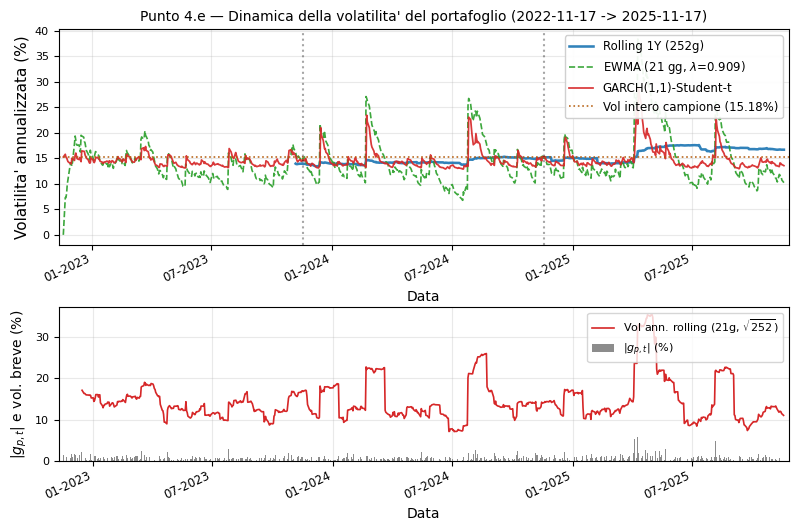

In [14]:
# =============================================================================
# PUNTO 4.e — La volatilità del portafoglio negli ultimi 3 anni appare costante
#            o mostra dinamiche significative? Approccio:
#   (i)   stima vol non parametrica (SMA rolling, EWMA, GARCH/EGARCH) su g_p;
#   (ii)  confronto vol per sotto-periodi e ratio max/min;
#   (iii) test statistici: ARCH-LM (Engle), Ljung-Box su g_p^2,
#         test di uguaglianza varianza fra sotto-finestre (Bartlett, Levene);
#   (iv)  figura riassuntiva e snippet LaTeX.
# =============================================================================

from scipy.stats import bartlett, levene  # Engle ARCH-LM e Ljung-Box importati piu' sotto

PORT_VOL_EWMA_DAYS = PORTFOLIO_VOL_ROLL_WINDOW_DAYS
PORT_VOL_EWMA_LAMBDA = ewma_lambda_from_span(PORT_VOL_EWMA_DAYS)
PORT_VOL_GARCH_RESCALE = 100.0
PORT_VOL_SUBSAMPLE_SPLITS = 3
PORT_VOL_ARCH_LM_LAGS = 10
PORT_VOL_LJUNG_BOX_LAGS = (5, 10, 20)


def _engle_arch_lm(resid: np.ndarray, lags: int) -> tuple[float, float, int]:
    """Engle (1982) ARCH-LM su residui: regredisce e_t^2 su intercept + e_{t-i}^2 (i=1..lags)."""
    e2 = np.asarray(resid, dtype=float) ** 2
    e2 = e2[~np.isnan(e2)]
    n = len(e2)
    if n <= lags + 5:
        return float("nan"), float("nan"), 0
    y = e2[lags:]
    X = np.ones((n - lags, lags + 1), dtype=float)
    for k in range(1, lags + 1):
        X[:, k] = e2[lags - k : n - k]
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    y_hat = X @ beta
    ss_res = float(np.sum((y - y_hat) ** 2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    if ss_tot <= 0:
        return float("nan"), float("nan"), n - lags
    r2 = 1.0 - ss_res / ss_tot
    lm_stat = (n - lags) * r2
    p_val = 1.0 - stats.chi2.cdf(lm_stat, df=lags)
    return float(lm_stat), float(p_val), int(n - lags)


def _ljung_box(x: np.ndarray, lags: int) -> tuple[float, float]:
    """Ljung-Box (1978) Q-statistic su serie x, fino a `lags` autocorrelazioni."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    x = x - x.mean()
    n = len(x)
    if n <= lags + 2:
        return float("nan"), float("nan")
    var0 = float(np.dot(x, x) / n)
    Q = 0.0
    for k in range(1, lags + 1):
        ck = float(np.dot(x[: n - k], x[k:]) / n)
        rho_k = ck / var0 if var0 > 0 else 0.0
        Q += rho_k * rho_k / max(1, n - k)
    Q *= n * (n + 2)
    p_val = 1.0 - stats.chi2.cdf(Q, df=lags)
    return float(Q), float(p_val)


def _vol_subperiod_stats(g: pd.Series, n_splits: int = PORT_VOL_SUBSAMPLE_SPLITS) -> pd.DataFrame:
    g = g.dropna().astype(float)
    bounds = np.linspace(0, len(g), n_splits + 1, dtype=int)
    rows = []
    for k in range(n_splits):
        chunk = g.iloc[bounds[k] : bounds[k + 1]]
        if len(chunk) < 5:
            continue
        rows.append(
            {
                "subperiod": f"P{k + 1}",
                "start": chunk.index.min().date(),
                "end": chunk.index.max().date(),
                "n_obs": int(len(chunk)),
                "sigma_daily": float(chunk.std(ddof=1)),
                "sigma_ann_sqrt252": float(chunk.std(ddof=1) * np.sqrt(252.0)),
            }
        )
    return pd.DataFrame(rows).set_index("subperiod")


def _fit_garch_egarch_portfolio(g: pd.Series) -> tuple[pd.Series, pd.Series, dict]:
    """GARCH(1,1)-t e EGARCH(1,1,1)-t su g_p * 100; ritorna vol ann. + parametri."""
    gy = g.dropna().astype(float) * PORT_VOL_GARCH_RESCALE
    idx = gy.index
    out_vols = {}
    out_par: dict = {}

    def _fit(build):
        try:
            return build().fit(update_freq=0, disp="off", options={"maxiter": 10_000})
        except Exception as exc:
            return exc

    res_g = _fit(
        lambda: arch_model(
            gy,
            mean="Constant",
            vol="GARCH",
            p=1,
            q=1,
            dist="studentst",
        )
    )
    if hasattr(res_g, "conditional_volatility"):
        sigma_d = pd.Series(res_g.conditional_volatility, index=idx) / PORT_VOL_GARCH_RESCALE
        out_vols["GARCH(1,1)-t"] = sigma_d * np.sqrt(252.0)
        out_par["GARCH(1,1)-t"] = {
            "omega": float(res_g.params.get("omega", np.nan)),
            "alpha[1]": float(res_g.params.get("alpha[1]", np.nan)),
            "beta[1]": float(res_g.params.get("beta[1]", np.nan)),
            "nu": float(res_g.params.get("nu", np.nan)),
            "persistence_alpha_plus_beta": float(res_g.params.get("alpha[1]", 0.0))
            + float(res_g.params.get("beta[1]", 0.0)),
            "AIC": float(res_g.aic),
            "BIC": float(res_g.bic),
        }

    res_e = _fit(
        lambda: arch_model(
            gy,
            mean="Constant",
            vol="EGARCH",
            p=1,
            o=1,
            q=1,
            dist="studentst",
        )
    )
    if hasattr(res_e, "conditional_volatility"):
        sigma_d = pd.Series(res_e.conditional_volatility, index=idx) / PORT_VOL_GARCH_RESCALE
        out_vols["EGARCH(1,1,1)-t"] = sigma_d * np.sqrt(252.0)
        out_par["EGARCH(1,1,1)-t"] = {
            "omega": float(res_e.params.get("omega", np.nan)),
            "alpha[1]": float(res_e.params.get("alpha[1]", np.nan)),
            "gamma[1]": float(res_e.params.get("gamma[1]", np.nan)),
            "beta[1]": float(res_e.params.get("beta[1]", np.nan)),
            "nu": float(res_e.params.get("nu", np.nan)),
            "AIC": float(res_e.aic),
            "BIC": float(res_e.bic),
        }

    sma252 = (g.rolling(252, min_periods=252).std(ddof=1) * np.sqrt(252.0)).rename("Rolling 1Y (252g)")
    sma21 = (g.rolling(21, min_periods=21).std(ddof=1) * np.sqrt(252.0)).rename("Rolling 1M (21g)")
    ewma = pd.Series(
        ewma_vol_ann_1m(g, span=PORT_VOL_EWMA_DAYS).values,
        index=g.index,
        name=label_ewma_window(PORT_VOL_EWMA_DAYS, PORT_VOL_EWMA_LAMBDA),
    )
    return sma252, sma21, {"ewma": ewma, "models": out_vols, "params": out_par}


sma252_pf, sma21_pf, _pack_pf = _fit_garch_egarch_portfolio(g_pf)
ewma_pf = _pack_pf["ewma"]
garch_pf_models = _pack_pf["models"]
garch_pf_params = _pack_pf["params"]
garch_pf_params_df = pd.DataFrame(garch_pf_params).T if garch_pf_params else pd.DataFrame()

# Statistiche di sintesi della vol nel tempo (su SMA 1Y disponibile)
roll1y_pf = sma252_pf.dropna()
if not roll1y_pf.empty:
    vol_min = float(roll1y_pf.min())
    vol_max = float(roll1y_pf.max())
    vol_mean = float(roll1y_pf.mean())
    vol_ratio_max_min = vol_max / vol_min if vol_min > 0 else float("nan")
    date_min = roll1y_pf.idxmin().date()
    date_max = roll1y_pf.idxmax().date()
else:
    vol_min = vol_max = vol_mean = vol_ratio_max_min = float("nan")
    date_min = date_max = None

subperiod_table_pf = _vol_subperiod_stats(g_pf, n_splits=PORT_VOL_SUBSAMPLE_SPLITS)

# Test di uguaglianza varianza tra sotto-periodi (su g_p centrato; Bartlett assume normalita',
# Levene e' robusto a deviazioni). H0: tutte le sotto-varianze uguali.
chunks_g = []
bounds = np.linspace(0, len(g_pf), PORT_VOL_SUBSAMPLE_SPLITS + 1, dtype=int)
for k in range(PORT_VOL_SUBSAMPLE_SPLITS):
    chunk = g_pf.iloc[bounds[k] : bounds[k + 1]].dropna().astype(float).values
    if len(chunk) > 10:
        chunks_g.append(chunk)

bart_stat = bart_p = lev_stat = lev_p = float("nan")
if len(chunks_g) >= 2:
    try:
        bart_stat, bart_p = bartlett(*chunks_g)
    except Exception:
        pass
    try:
        lev_stat, lev_p = levene(*chunks_g, center="median")
    except Exception:
        pass

resid_pf = (g_pf - g_pf.mean()).dropna().values
arch_lm_stat, arch_lm_p, arch_lm_n = _engle_arch_lm(resid_pf, lags=PORT_VOL_ARCH_LM_LAGS)
lb_results = {}
for lag in PORT_VOL_LJUNG_BOX_LAGS:
    q_stat, q_p = _ljung_box(resid_pf ** 2, lags=lag)
    lb_results[lag] = (q_stat, q_p)

tests_table = pd.DataFrame(
    {
        "stat": [
            bart_stat,
            lev_stat,
            arch_lm_stat,
            *(lb_results[lag][0] for lag in PORT_VOL_LJUNG_BOX_LAGS),
        ],
        "p_value": [
            bart_p,
            lev_p,
            arch_lm_p,
            *(lb_results[lag][1] for lag in PORT_VOL_LJUNG_BOX_LAGS),
        ],
    },
    index=[
        f"Bartlett (var. uguali, {len(chunks_g)} sotto-periodi)",
        f"Levene (var. uguali, {len(chunks_g)} sotto-periodi)",
        f"Engle ARCH-LM (lags={PORT_VOL_ARCH_LM_LAGS})",
        *(f"Ljung-Box su g_p^2 (lag={lag})" for lag in PORT_VOL_LJUNG_BOX_LAGS),
    ],
)

print("\n=== Punto 4.e — Volatilita' costante o dinamiche significative? ===")
print(
    f"Finestra 4.a: {t0_pf.date()} -> {t_end_pf.date()} ({len(g_pf)} log-rendimenti); "
    f"sotto-periodi disgiunti: {PORT_VOL_SUBSAMPLE_SPLITS}; "
    f"H0 dei test: nessuna eteroschedasticita' / varianze uguali."
)
print(
    f"Vol ann. rolling 1Y: min={vol_min*100:.2f}% ({date_min}), "
    f"max={vol_max*100:.2f}% ({date_max}), media={vol_mean*100:.2f}%, "
    f"ratio max/min={vol_ratio_max_min:.2f}."
)
display(subperiod_table_pf.round(6))
display(tests_table.round(6))
if not garch_pf_params_df.empty:
    print("Parametri vol condizionata (portafoglio):")
    display(garch_pf_params_df.round(5))


def _vol_judgment_pf() -> list[str]:
    out: list[str] = []
    if np.isfinite(vol_ratio_max_min) and vol_ratio_max_min > 1.5:
        out.append(
            f"La vol annualizzata rolling 1Y varia di un fattore {vol_ratio_max_min:.2f} (min {vol_min*100:.1f}% -> max {vol_max*100:.1f}%): non e' costante."
        )
    elif np.isfinite(vol_ratio_max_min):
        out.append(
            f"La vol rolling 1Y varia di un fattore {vol_ratio_max_min:.2f} (min {vol_min*100:.1f}% -> max {vol_max*100:.1f}%): variazioni moderate."
        )
    if np.isfinite(arch_lm_p):
        if arch_lm_p < 0.01:
            out.append(
                f"Engle ARCH-LM (lags={PORT_VOL_ARCH_LM_LAGS}): p={arch_lm_p:.2e} -> forte evidenza di eteroschedasticita' condizionata (volatility clustering)."
            )
        elif arch_lm_p < 0.05:
            out.append(
                f"Engle ARCH-LM (lags={PORT_VOL_ARCH_LM_LAGS}): p={arch_lm_p:.3f} -> evidenza significativa di eteroschedasticita'."
            )
        else:
            out.append(f"Engle ARCH-LM (lags={PORT_VOL_ARCH_LM_LAGS}): p={arch_lm_p:.3f} -> non si rifiuta H0 (varianza condizionata costante).")
    if np.isfinite(lev_p):
        if lev_p < 0.05:
            out.append(
                f"Levene su {len(chunks_g)} sotto-periodi: p={lev_p:.3f} -> sotto-varianze diverse (eteroschedasticita' inter-periodo)."
            )
        else:
            out.append(f"Levene su sotto-periodi: p={lev_p:.3f} -> varianze inter-periodo non distinguibili.")
    if "GARCH(1,1)-t" in garch_pf_params:
        ab = garch_pf_params["GARCH(1,1)-t"].get("persistence_alpha_plus_beta", float("nan"))
        if np.isfinite(ab):
            if ab > 0.95:
                out.append(
                    f"Persistenza GARCH(1,1) alpha+beta={ab:.3f}: shock di volatilita' altamente persistenti."
                )
            elif ab > 0.85:
                out.append(f"Persistenza GARCH(1,1) alpha+beta={ab:.3f}: persistenza marcata.")
            else:
                out.append(f"Persistenza GARCH(1,1) alpha+beta={ab:.3f}: dinamiche presenti ma poco persistenti.")
    return out


vol_judgment_lines = _vol_judgment_pf()
print("\nGiudizio sintetico (4.e):")
for line in vol_judgment_lines:
    print(" -", line)

_gp = garch_pf_params.get("GARCH(1,1)-t", {})
_persist_gp = float(_gp.get("persistence_alpha_plus_beta", float("nan")))
# Conclusione adattiva: deriva dal test ARCH-LM, non hardcoded
_arch_lm_rifiuta = np.isfinite(arch_lm_p) and arch_lm_p < 0.05
_conclusione_vol = "\\emph{non} appare costante" if _arch_lm_rifiuta else "appare sostanzialmente costante"

REPORT_PUNTO4E_SNIPPET_LATEX = rf"""
\subsection*{{Dinamica della volatilita' (Punto 4.e)}}
Sul portafoglio 4.a (campione $n={len(g_pf)}$, finestra ${t0_pf.date()} \to {t_end_pf.date()}$) la
volatilita' {_conclusione_vol}. La vol annualizzata in finestra rolling 1Y varia da
{vol_min*100:.2f}\% ({date_min}) a {vol_max*100:.2f}\% ({date_max}), con ratio max/min pari a
{vol_ratio_max_min:.2f}. Il test di Engle ARCH-LM (lags={PORT_VOL_ARCH_LM_LAGS}) restituisce
$p={arch_lm_p:.2e}$ e il Ljung-Box su $g_{{p,t}}^2$ con $20$ ritardi
$Q={lb_results[20][0]:.2f}$, $p={lb_results[20][1]:.2e}$. Il modello
GARCH(1,1)-Student-t stimato presenta persistenza
$\hat\alpha_1+\hat\beta_1={_persist_gp:.3f}$.
Levene su {PORT_VOL_SUBSAMPLE_SPLITS} sotto-periodi: $p={lev_p:.3f}$ (uguaglianza varianze
inter-periodo); Bartlett: $p={bart_p:.3f}$ (sensibile alla non-normalita', meno robusto).
""".strip()

print("\n--- Snippet LaTeX (Punto 4.e) ---\n")
print(REPORT_PUNTO4E_SNIPPET_LATEX)

if SAVE_FIGS:
    try:
        os.makedirs(FIG_DIR, exist_ok=True)
        subperiod_table_pf.to_csv(os.path.join(FIG_DIR, "p4e_vol_subperiod_table.csv"))
        tests_table.to_csv(os.path.join(FIG_DIR, "p4e_vol_dynamics_tests.csv"))
        if not garch_pf_params_df.empty:
            garch_pf_params_df.to_csv(os.path.join(FIG_DIR, "p4e_portfolio_vol_model_params.csv"))
        with open(os.path.join(FIG_DIR, "p4e_report_snippet_vol_dynamics.tex"), "w", encoding="utf-8") as f:
            f.write("% --- Generato: dinamica vol punto 4.e ---\n\n")
            f.write(REPORT_PUNTO4E_SNIPPET_LATEX + "\n")
        print(f"[SAVE] CSV/LaTeX Punto 4.e in {os.path.abspath(FIG_DIR)}")
    except OSError as e:
        print(f"[SAVE] Punto 4.e export fallito: {e}")

fig_p4e, (ax_v, ax_p) = plt.subplots(
    2,
    1,
    figsize=(8.2, 6.0),
    sharex=False,
    gridspec_kw={"height_ratios": [1.4, 1.0], "hspace": 0.34},
)

# Figura report: 3 stime (rolling lunga, EWMA breve, GARCH) — EGARCH resta in tabella export
_PLOT_ALPHA = 0.92
if not sma252_pf.dropna().empty:
    ax_v.plot(
        sma252_pf.index,
        sma252_pf.values * 100.0,
        color="#1f77b4",
        linewidth=1.85,
        alpha=_PLOT_ALPHA,
        label="Rolling 1Y (252g)",
    )
if not ewma_pf.dropna().empty:
    ax_v.plot(
        ewma_pf.index,
        ewma_pf.values * 100.0,
        color="#2ca02c",
        linewidth=1.2,
        linestyle="--",
        alpha=_PLOT_ALPHA,
        label=label_ewma_window(PORT_VOL_EWMA_DAYS, PORT_VOL_EWMA_LAMBDA),
    )
_garch_pf = garch_pf_models.get("GARCH(1,1)-t")
if _garch_pf is not None and not _garch_pf.dropna().empty:
    ax_v.plot(
        _garch_pf.dropna().index,
        _garch_pf.dropna().values * 100.0,
        color="#d62728",
        linewidth=1.25,
        alpha=_PLOT_ALPHA,
        label="GARCH(1,1)-Student-t",
    )
ax_v.axhline(
    sigma_ann_full * 100.0,
    color="#b35806",
    linestyle=":",
    linewidth=1.2,
    alpha=0.9,
    label=f"Vol intero campione ({sigma_ann_full * 100:.2f}%)",
    zorder=2,
)

# Linee verticali ai bounds dei sotto-periodi
for k in range(1, PORT_VOL_SUBSAMPLE_SPLITS):
    idx_b = bounds[k]
    if 0 < idx_b < len(g_pf):
        ax_v.axvline(g_pf.index[idx_b], color="black", linestyle=":", alpha=0.35)

ax_v.set_ylabel("Volatilita' annualizzata (%)", fontsize=11)
ax_v.set_title(
    f"Punto 4.e — Dinamica della volatilita' del portafoglio ({t0_pf.date()} -> {t_end_pf.date()})"
)
ax_v.grid(True, alpha=0.28)
ax_v.legend(loc="upper right", fontsize=8.5, framealpha=0.92, ncol=1)

# Pannello sotto: |g_p| nel tempo (proxy di vol istantanea) + sigma rolling 1M
abs_g = (g_pf.abs() * 100.0)
ax_p.bar(abs_g.index, abs_g.values, color="#8c8c8c", width=1.0, alpha=1, label=r"$|g_{p,t}|$ (%)")
if not sma21_pf.dropna().empty:
    ax_p.plot(
        sma21_pf.index,
        sma21_pf.values * 100.0,
        color="#d62728",
        linewidth=1.2,
        label=f"Vol ann. rolling ({PORTFOLIO_VOL_ROLL_WINDOW_DAYS}g, $\\sqrt{{252}}$)",
    )
ax_p.set_ylabel(r"$|g_{p,t}|$ e vol. breve (%)", fontsize=10)
ax_p.set_xlabel("Data", fontsize=10)
ax_p.grid(True, alpha=0.28)
ax_p.legend(loc="upper right", fontsize=8)

fig_p4e.subplots_adjust(left=0.08, right=0.97, top=0.86, bottom=0.14, hspace=0.50)
finalize_date_axes((ax_v, ax_p), g_pf.index, fontsize=8.5, rotation=25.0)
ax_v.set_xlabel("Data", fontsize=10)
ax_p.set_xlabel("Data", fontsize=10)
maybe_save(fig_p4e, "p4e_portfolio_vol_dynamics")
plt.show()
plt.close(fig_p4e)


In [13]:
REPORT_FIGURE_MANIFEST = [
    "p1_prices_normalized_report",
    "p2_returns_summary",
    "p2_vol_summary_static_vs_roll1y",
    "p2_corr_heatmap",
    "p2_corr_pvalues_heatmap",
    "p2_vol_overlay_roll_ewma_garch_panels",
    "p3_var_summary_and_oos_exceedance",
    "p4a_portfolio_constant_weights_3y",
    "p4b_portfolio_log_returns_and_rolling_vol",
    "p4c_portfolio_var_usd_and_correlations",
    "p4d_diversification_correlations_and_var_impact",
    "p4e_portfolio_vol_dynamics",
]
REPORT_FIGURE_OPTIONAL = ["p2_correlations_report", "p2_boxplot_logreturns"]


def run_validation_checks() -> None:
    """Controlli incrociati post-stima (matematica / consegna)."""
    checks: list[str] = []
    # Pesi
    if not np.isclose(float(PORTFOLIO_WEIGHTS_EQUITY.sum() + PORTFOLIO_WEIGHT_CASH), 1.0):
        checks.append("ERRORE: pesi non sommano a 1")
    # correlazione vs scipy (prima coppia)
    a, b = returns_lw.iloc[:, 0], returns_lw.iloc[:, 1]
    rho = float(R.iloc[0, 1])
    t_man = rho * np.sqrt((n_obs_lw - 2) / (1 - rho**2))
    p_man = 2 * (1 - stats.t.cdf(abs(t_man), df=n_obs_lw - 2))
    _, p_sp = stats.pearsonr(a, b)
    if abs(float(P.iloc[0, 1]) - p_man) > 1e-8 or abs(float(P.iloc[0, 1]) - p_sp) > 1e-6:
        checks.append("ERRORE: test correlazione non coerente")
    # VaR parametrico spot
    g0 = returns_log.iloc[:, 0].dropna()
    z = stats.norm.ppf(VAR_ALPHA)
    v_ref = -(float(g0.mean()) + float(g0.std(ddof=1)) * z)
    v_code = float(
        _var_positive_loss_from_logret(g0, alpha=VAR_ALPHA, horizon=1, method="parametric")
    )
    if abs(v_ref - v_code) > 1e-8:
        checks.append("ERRORE: VaR parametrico marginale")
    # VaR portafoglio: parametrico vs MC (stessa Sigma)
    if (
        np.isfinite(var_g_pf_param)
        and np.isfinite(var_g_pf_mc)
        and var_g_pf_param > 0
    ):
        rel_diff = abs(var_g_pf_param - var_g_pf_mc) / var_g_pf_param
        if rel_diff > 0.08:
            checks.append(
                f"ATTENZIONE: VaR portafoglio MC discosta {rel_diff:.1%} dal parametrico"
            )
        if not np.isclose(mu_p_param, mu_p_mc, rtol=1e-9):
            checks.append("ERRORE: mu_p MC != mu_p parametrico")
        if not np.isclose(sigma_p_param, sigma_p_mc, rtol=1e-9):
            checks.append("ERRORE: sigma_p MC != sigma_p parametrico")
    if checks:
        print("\n=== VALIDAZIONE: problemi rilevati ===")
        for c in checks:
            print(" -", c)
    else:
        print("\n=== VALIDAZIONE: controlli matematici OK (pesi, correlazioni, VaR) ===")


if SAVE_FIGS:
    absdir = os.path.abspath(FIG_DIR)
    if os.path.isdir(absdir):
        pdfs = sorted(f for f in os.listdir(absdir) if f.endswith(".pdf"))
        print(f"\n=== Figure report (PDF) in {absdir} — {len(pdfs)} file ===")
        for name in REPORT_FIGURE_MANIFEST:
            ok = os.path.isfile(os.path.join(absdir, name + ".pdf"))
            print(f"  [{'OK' if ok else '--'}] {name}.pdf")
        print(f"\nTotale PDF in cartella: {len(pdfs)} (target report ~{len(REPORT_FIGURE_MANIFEST)} figure)")
    else:
        print(f"\n=== SAVE_FIGS=True ma cartella assente: {absdir} ===")
else:
    print("\n=== Salvataggio figure disattivo (SAVE_FIGS=False) ===")

run_validation_checks()



=== Figure report (PDF) in /content/figures — 13 file ===
  [OK] p1_prices_normalized_report.pdf
  [OK] p2_returns_summary.pdf
  [OK] p2_vol_summary_static_vs_roll1y.pdf
  [OK] p2_corr_heatmap.pdf
  [OK] p2_corr_pvalues_heatmap.pdf
  [OK] p2_vol_overlay_roll_ewma_garch_panels.pdf
  [OK] p3_var_summary_and_oos_exceedance.pdf
  [OK] p4a_portfolio_constant_weights_3y.pdf
  [OK] p4b_portfolio_log_returns_and_rolling_vol.pdf
  [OK] p4c_portfolio_var_usd_and_correlations.pdf
  [OK] p4d_diversification_correlations_and_var_impact.pdf
  [OK] p4e_portfolio_vol_dynamics.pdf

Totale PDF in cartella: 13 (target report ~12 figure)

=== VALIDAZIONE: controlli matematici OK (pesi, correlazioni, VaR) ===
